# B± → π±π±π∓ — QMI independente por carga, constante por bin

Primeiro ajustamos os dados com os nove isóbaros do notebook 23 SqDP; depois
substituímos `sigma0 + f0_980 + f0_1370` por QMI independente para B+ e B−,
com **25 bins constantes**, nos limites exatos da Tabela 28. `chi_c0` fica separado.
Os 26 valores em `QMI_KNOTS_GEV` são bordas; há 25 amplitudes complexas por carga.
A semente é a onda-S isobárica avaliada nos centros dos bins.

O coeficiente externo permanece fixo em `1+0i`. Todos os bins fora do veto são
livres, inclusive o primeiro. O bin 20, inteiramente dentro do veto D0, fica
fixo em zero nas duas cargas por não ter sensibilidade na amostra selecionada.
Não há interpolação nem penalidade de suavidade. São 96 parâmetros de bins
mais 21 coeficientes dos demais isóbaros: 117 parâmetros livres.

Nenhuma amplitude é normalizada individualmente em nenhum dos fits.
A densidade total continua normalizada conjuntamente em B+/B− com interferências.
As massas/larguras continuam fixas; os gráficos de comparação usam os mesmos bins
da referência. Os outputs devem ser regenerados com um novo fit.


In [36]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dalitzplotfitter import (
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DecayChannel,
    DecayModel,
    GounarisSakurai,
    MassWindowVeto,
    Parameter,
    PhaseSpaceSample,
    QMI,
    RealImag,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    RelativisticBreitWigner,
    Resonance,
    SigmaPole,
    ZemachP,
    enable_x64,
    delta_method_errors,
    read_root_histogram2d,
    read_root_tree,
    kdtree_local_residuals,
)

enable_x64()

## Configuração e proveniência dos inputs

Dados, mapas, yields e assimetrias iniciais são preservados conforme solicitado pelo usuário,
a partir de `GenFit3piCP_R2_415489.cc`. A diferença de yields para a Tabela 3 do draft
é uma limitação explícita da reprodução, não uma alteração a aplicar ao ROOT atual.


In [ ]:
INPUTS = Path("/Users/juanleite/Work/data/fit415489_pipipinotav3_21-5--11h32m13s415489/inputs")

DATA_FILE = INPUTS / "data15161718_pipipi_LauNoSpike.root"
DATA_TREE = "fitTree"

ACC_FILE = INPUTS / "ACC_pipipi_15161718_NoSpike_prodAsy.root"
ACC_HIST_PLUS = "Hacc_pipipi_15161718_Plus"
ACC_HIST_MINUS = "Hacc_pipipi_15161718_Minus"

QQBAR_BKG_FILE = INPUTS / "Lau_3pi_BKG_pm_322_V2h_splot_normcut.root"
QQBAR_HIST_PLUS = "hbkgbp"
QQBAR_HIST_MINUS = "hbkgbm"

KPIPI_BKG_FILE = INPUTS / "bkg_kpipi_histo.root"
KPIPI_HIST = "hbkg"  # same histogram used for both B+ and B- in the .cc

D0_VETO_MIN_GEV = 1.74
D0_VETO_MAX_GEV = 1.894

N_TOTAL_EVENTS = 95110.0
SIGNAL_FRACTION = 0.8845
QQBAR_FRACTION = 0.1155
N_SIGNAL = N_TOTAL_EVENTS * SIGNAL_FRACTION
N_QQBAR = N_TOTAL_EVENTS * QQBAR_FRACTION
QQBAR_YIELD_ASYMMETRY = -0.0078  # qqbarEventsAsym, fixed

N_KPIPIBKG = 0. # nBgkpipiEvents = 95120*.0, fixed -- inert, kept only for structural fidelity
KPIPIBKG_YIELD_ASYMMETRY = 0.03  # kpipibkgEventsAsym, fixed -- inert since the yield above is 0


print(f"N_signal = {N_SIGNAL:.3f}   N_qqbar = {N_QQBAR:.3f}   sum = {N_SIGNAL + N_QQBAR:.3f}")

NORMALIZATION_CONFIG = {
    "normalization_method": "square-dalitz",
    #"normalization_method": "gauss-legendre",
    "normalization_pair": (2,0),
    #"normalization_binning_factor": 30,
    "normalization_chunk_size": 300_000,
    "dynamics_microbatch_size": 300_000,
    "normalization_resolution": 500
}

N_signal = 84124.795   N_qqbar = 10985.205   sum = 95110.000


## Canais e veto

`DecayChannel` resolve massa do pai e das filhas via o pacote `particle`; usamos essas mesmas
massas para as coordenadas Square-Dalitz do ACC/background abaixo, garantindo consistência interna
com o que `DecayModel` usa.

In [38]:
PLUS_CHANNEL = DecayChannel("B+", ("pi+", "pi+", "pi-"))
MINUS_CHANNEL = DecayChannel("B-", ("pi-", "pi-", "pi+"))

MOTHER_MASS = PLUS_CHANNEL.parent_mass
DAUGHTER_MASSES = PLUS_CHANNEL.daughter_masses
SQDP_PAIR = (0, 1)  # the two identical pi+/pi-, per the sibling Laura-toy benchmark notebook
RESONANCE_PAIR = (2, 0)  # resPairAmpInt=2 for every resonance in the .cc

print("mother mass [GeV] =", MOTHER_MASS)
print("daughter masses [GeV] =", DAUGHTER_MASSES)

D0_VETO = CompositeVeto(
    MassWindowVeto((0, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
    MassWindowVeto((1, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
)


mother mass [GeV] = 5.2794099999999995
daughter masses [GeV] = (0.13957039000000002, 0.13957039000000002, 0.13957039000000002)


## Dados

Os invariantes são lidos como `s12=m12Sq`, `s13=m13Sq`, `s23=m23Sq`, com a carga ±1.
O ROOT atual já está dobrado (`s13 <= s23`): isso é compatível com a amplitude simétrica,
mas exige dobrar as expectativas nos diagnósticos. O filtro por carga é explícito.

In [39]:
def _load_charge_sample(charge_value):
    raw = read_root_tree(
        DATA_FILE, DATA_TREE,
        {"s12": "m12Sq", "s13": "m13Sq", "s23": "m23Sq", "charge": "charge"},
    )
    mask = np.asarray(raw["charge"]) == charge_value
    n = int(mask.sum())
    sample = PhaseSpaceSample(
        s12=jnp.asarray(raw["s12"])[mask],
        s13=jnp.asarray(raw["s13"])[mask],
        s23=jnp.asarray(raw["s23"])[mask],
        weights=jnp.ones(n, dtype=jnp.float64),
    )
    return D0_VETO.apply(sample)


plus_data = _load_charge_sample(+1)
minus_data = _load_charge_sample(-1)

print(f"B+ events (post D0 veto): {plus_data.size:,}")
print(f"B- events (post D0 veto): {minus_data.size:,}")
print(f"total: {plus_data.size + minus_data.size:,}  (fitTree has 95110 entries, 0 in the D0 window)")

for label, sample in (("B+", plus_data), ("B-", minus_data)):
    print(label, "fraction s13 <= s23:", float(jnp.mean(sample.s13 <= sample.s23)))
if plus_data.size + minus_data.size != int(N_TOTAL_EVENTS):
    raise ValueError("Observed event count differs from the input yield configuration")

B+ events (post D0 veto): 43,723
B- events (post D0 veto): 51,387
total: 95,110  (fitTree has 95110 entries, 0 in the D0 window)
B+ fraction s13 <= s23: 1.0
B- fraction s13 <= s23: 1.0


## Eficiência (ACC)

Histogramas `Hacc_pipipi_15161718_Plus`/`Minus` em `(m', theta')`, `theta' in [0, 0.5]`
(`useUpperHalf=kTRUE` no Laura++) $\Rightarrow$ `folded=True`. `SquareDalitzHistogramEfficiency`
troca a busca por bin mais próximo pela interpolação bilinear do
Laura++ (`Lau2DHistDP::interpolateXY`); a eficiência é uma razão adimensional, então não leva
correção de jacobiano.

In [40]:
def _load_square_dalitz_histogram2d(file_path, histogram):
    values, mp_edges, tp_edges = read_root_histogram2d(file_path, histogram)
    return jnp.asarray(values), jnp.asarray(mp_edges), jnp.asarray(tp_edges)


def _laura_efficiency(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline", clip=True,
    )


plus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_PLUS)
minus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_MINUS)
print("ACC B+ grid:", plus_efficiency.values.shape, "  ACC B- grid:", minus_efficiency.values.shape)

ACC B+ grid: (30, 30)   ACC B- grid: (30, 30)


## Background `qqbar` e `kpipibkg`

`SquareDalitzHistogramBackground` aplica a mesma interpolação bilinear e, além
disso, divide pelo jacobiano `|d(s13,s23)/d(m',theta')|` -- o histograma armazena uma densidade em
`(m', theta')` (`Lau2DHistDPPdf`), mas a amostra de normalização/a verossimilhança trabalham em
`(s13, s23)`. As duas ressonâncias de background do `.cc` são carregadas aqui; `kpipibkg` usa o
mesmo histograma `hbkg` para B+ e B- (como no `.cc`). O escalonamento pela assimetria de yield fixa
de cada uma (`qqbarEventsAsym=-0.0078`, `kpipibkgEventsAsym=0.03`) é feito mais abaixo, depois que
`plus_model`/`minus_model` existem -- o método `with_charge_asymmetry` normaliza cada forma pela sua
integral pós-veto *na mesma amostra de normalização/quadratura usada pelo ajuste* antes de aplicar
`(1 ∓ asym)`, reproduzindo exatamente `bkgndEvents = N_bkg * 0.5 * (1 - carga*asym)` do
`LauCPFitModel.cc`.

Na avaliação do PDF, `divide_jacobian=True` faz a conversão para a densidade em
`(s13,s23)`. Para geração, os geradores usam o método `generation_value()` da
classe, que retorna o valor bruto interpolado sem essa divisão, seguindo
`LauBkgndDPModel::generate` do Laura++.

In [41]:
def _laura_background(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramBackground(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline",  divide_jacobian=True,
    )


_qqbar_plus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_PLUS)
_qqbar_minus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_MINUS)
_kpipibkg_pdf = _laura_background(KPIPI_BKG_FILE, KPIPI_HIST)

print("qqbar B+ grid:", _qqbar_plus_pdf.values.shape, "  qqbar B- grid:", _qqbar_minus_pdf.values.shape)
print("kpipibkg grid:", _kpipibkg_pdf.values.shape)

qqbar B+ grid: (60, 30)   qqbar B- grid: (60, 30)
kpipibkg grid: (15, 15)


## Modelo isobárico de referência

Nove componentes e massas/larguras fixas do notebook 23 (SqDP). Os coeficientes
CP abaixo são apenas valores iniciais: serão reajustados aos dados reais na base
sem normalização individual. A referência é `rho0_770.x=1`, `y=dy=0`.


In [42]:
# Modelo de referência: 23_b2pipipi_cpvfit_toy_pull_study_SqDP.ipynb, célula 14.
# Massas/larguras fixas e coeficientes de partida copiados; nenhuma amplitude normalizada.
COEFFICIENT_SPECS = {
    "rho0_770":    (1.00000e+00,  0.00000e+00,  1.02312e-03,  0.00000e+00, True,  True,  False, True),
    "omega_782":   (-3.03268e-02, 9.48849e-02,  7.29877e-03,  1.38260e-02, False, False, False, False),
    "rho0_1450":   (-2.70865e-01, 1.13529e-01, -9.16491e-02, -7.71941e-03, False, False, False, False),
    "f2_1270":     (3.51291e-01,  1.71931e-01, -5.45892e-02, -1.17944e-01, False, False, False, False),
    "rho0_3_1690": (9.64994e-02,  1.91968e-02,  4.92371e-02,  5.41424e-02, False, False, False, False),
    "sigma0":      (-4.02003e-01, 3.57099e-01,  2.86690e-01,  2.01322e-01, False, False, False, False),
    "f0_980":      (1.41060e-01, -1.40500e-02, -4.50930e-02, -7.70899e-02, False, False, False, False),
    "chi_c0":      (2.71432e-02,  1.41733e-02, -4.02037e-02, -4.02666e-02, False, False, False, False),
    "f0_1370":     (1.00608e-01, -2.34739e-02,  5.11699e-02, -5.63136e-02, False, False, False, False),
}

DYNAMICS_SPECS = {
    "rho0_770":    (0.770229, 0.148864, True, (0.60, 0.95), (0.05, 0.30)),
    "omega_782":   (0.78265, 0.00849, True,  None, None),
    "rho0_1450":   (1.46500, 0.40000, True,  None, None),
    "f2_1270":     (1.25071, 0.170502, True, (1.10, 1.40), (0.05, 0.35)),
    "rho0_3_1690": (1.68600, 0.18600, True,  None, None),
    "sigma0":      (0.509084, 0.425813, True, (0.30, 0.70), (0.20, 0.90)),
    "f0_980":      (0.976535, 0.047831, True, (0.85, 1.10), (0.01, 0.20)),
    "chi_c0":      (3.41471, 0.01310, True,  None, None),
    "f0_1370":     (1.50218, 0.173547, True, (1.10, 1.80), (0.05, 0.60)),
}

SPINS = {
    "rho0_770": 1, "omega_782": 1, "rho0_1450": 1, "f2_1270": 2, "rho0_3_1690": 3,
    "sigma0": 0, "f0_980": 0, "chi_c0": 0, "f0_1370": 0,
}

LINESHAPES = {
    "rho0_770": GounarisSakurai, "omega_782": RelativisticBreitWigner,
    "rho0_1450": GounarisSakurai, "f2_1270": RelativisticBreitWigner,
    "rho0_3_1690": RelativisticBreitWigner, "sigma0": SigmaPole,
    "f0_980": RelativisticBreitWigner, "chi_c0": RelativisticBreitWigner,
    "f0_1370": RelativisticBreitWigner,
}

def make_shared_coefficients(values=None):
    values = {} if values is None else values
    coefficients = {}
    for name, (x0, y0, dx0, dy0, fx, fy, fdx, fdy) in COEFFICIENT_SPECS.items():
        x0, y0, dx0, dy0 = (values.get(f"{name}.{key}", start)
                              for key, start in zip(("x", "y", "dx", "dy"), (x0, y0, dx0, dy0)))
        x = Parameter.coefficient(f"{name}.x", x0, owner=name, fixed=fx)
        y = Parameter.coefficient(f"{name}.y", y0, owner=name, fixed=fy)
        dx = Parameter.coefficient(
            f"{name}.dx", dx0, owner=name, fixed=fdx,
            bounds=(-0.999999, 0.999999) if name == "rho0_770" else None,
        )
        dy = Parameter.coefficient(f"{name}.dy", dy0, owner=name, fixed=fdy)
        coefficients[name] = CPRealImag(x, y, dx, dy)
    return coefficients


def make_dynamics_parameters(values=None):
    values = {} if values is None else values
    dynamics = {}
    for name, (mass0, width0, fixed, mass_bounds, width_bounds) in DYNAMICS_SPECS.items():
        dynamics[f"{name}.mass"] = Parameter.dynamics(
            f"{name}.mass", values.get(f"{name}.mass", mass0), owner=name, fixed=fixed,
            bounds=None if fixed else mass_bounds,
        )
        dynamics[f"{name}.width"] = Parameter.dynamics(
            f"{name}.width", values.get(f"{name}.width", width0), owner=name, fixed=fixed,
            bounds=None if fixed else width_bounds,
        )
    return dynamics

## Fit isobárico nos dados → semente QMI

Primeiro ajustamos os nove isóbaros aos mesmos dados, eficiência, veto e backgrounds
utilizados pelo QMI. Nenhum componente é normalizado individualmente.
Após um fit válido, a soma bruta `sigma0 + f0_980 + f0_1370` é avaliada nos centros dos bins,
separadamente por carga, com os coeficientes CP ajustados. `chi_c0` permanece separado.
Os seis isóbaros restantes também começam dos parâmetros ajustados. A QMI constante por bin aproxima essa soma; não há reescalonamento da semente.


In [43]:
SWAVE_NAMES = ("sigma0", "f0_980", "f0_1370")
isobar_shared = make_shared_coefficients()
isobar_dynamics = make_dynamics_parameters()


def build_isobar_components(charge):
    return [
        Resonance(
            name, RESONANCE_PAIR, isobar_shared[name].for_charge(charge),
            lineshape=LINESHAPES[name](), angular=ZemachP(),
            normalize_component=False,
            mass=isobar_dynamics[f"{name}.mass"], width=isobar_dynamics[f"{name}.width"],
            spin=SPINS[name], resonance_radius=4.0, parent_radius=4.0,
        )
        for name in LINESHAPES
    ]


isobar_models = {
    charge: DecayModel(channel, build_isobar_components(charge),
                       normalize_components=False, **NORMALIZATION_CONFIG)
    for charge, channel in ((+1, PLUS_CHANNEL), (-1, MINUS_CHANNEL))
}


def make_data_fit_session(plus, minus):
    session = CPFitSession(
        plus, minus, plus_data, minus_data, extended=True,
        signal_yield=Parameter("n_signal", N_SIGNAL, fixed=True),
    ).with_efficiency(plus_efficiency, minus_efficiency).with_veto(D0_VETO)
    for name, plus_pdf, minus_pdf, asymmetry, count in (
        ("qqbar", _qqbar_plus_pdf, _qqbar_minus_pdf, QQBAR_YIELD_ASYMMETRY, N_QQBAR),
        ("kpipibkg", _kpipibkg_pdf, _kpipibkg_pdf, KPIPIBKG_YIELD_ASYMMETRY, N_KPIPIBKG),
    ):
        session = session.with_background(
            name,
            plus_pdf.with_charge_asymmetry(plus.normalization_sample, veto=D0_VETO,
                                           asymmetry=asymmetry, charge=+1),
            minus_shape=minus_pdf.with_charge_asymmetry(
                minus.normalization_sample, veto=D0_VETO, asymmetry=asymmetry, charge=-1),
            yield_=Parameter(f"n_{name}", count, fixed=True),
        )
    return session


isobar_session = make_data_fit_session(isobar_models[+1], isobar_models[-1])
isobar_result = isobar_session.fit(strategy=1, verbose=3, hesse=True, hessian="jax")
print(isobar_result.fmin)
if not isobar_result.valid:
    raise RuntimeError("Fit isobárico inválido: verificar MIGRAD/EDM antes de inicializar o QMI")
isobar_values = isobar_session.result_values(isobar_result)
isobar_session.print_result(isobar_result)


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=3.414710 GeV, Gamma=13.100 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=3.414710 GeV, Gamma=13.100 MeV); applying adaptive Square-Dalitz refinement only along the mass axis m'. Grid: 2936 m' nodes x 500 theta' nodes (1,468,000 points; base 250,000).
INFO DalitzPlotFitter normalization: crossed narrow band(s) are kept on the standard theta' resolution; only resonances aligned with normalization_pair refine m'.
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=3.414710 GeV, Gamma=13.100 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=3.414710 GeV, Gamma=13.100 MeV); applying adaptive Square-Dalitz refinement only along the mass axis m'. Grid: 2936 m' nodes x 500 theta' nodes (1,468,000 points; base 250,000).
INFO DalitzPlotFitter normalization: crossed narrow band(s) are kept on the standard 

/Users/juanleite/Work/DalitzPlotFitter/.venv/lib/python3.13/site-packages/iminuit/minuit.py:733: IMinuitWarning: hessian overrides g2, passing g2 has no effect
  warnings.warn(


I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
I NegativeG2LineSearch Done after 105.097 ms
I MnSeedGenerator Initial seeding state  
  Minimum value : -461987.0531
  Edm           : 19151.86038
  Internal parameters:	[   0.001023121202     0.5601628523        0.0948849       0.00729877         0.013826        -0.270865         0.113529       -0.0916491      -0.00771941         0.351291....        -0.0563136]	
  Internal gradient  :	[      1050.481707     -3312.039958     -1752.561107      2101.551178     -3848.279989      -291.820169     -330.7168294      45.87419803      365.0681453     -557.8866057....       10.25622756]	
  Internal covariance matrix:
[[   0.0043913048              0              0              0              0              0              0              0              0              0....               0]
 [              0  3.9093168e-05              0              0              0              0              0         

{'rho0_770.x': 1.0,
 'rho0_770.y': 0.0,
 'rho0_770.dx': 0.0008872114218734184,
 'rho0_770.dy': 0.0,
 'rho0_770.mass': 0.770229,
 'rho0_770.width': 0.148864,
 'omega_782.x': -0.00793557109763669,
 'omega_782.y': 0.02471899886211695,
 'omega_782.dx': 0.0018589259424743587,
 'omega_782.dy': 0.003617229262103615,
 'omega_782.mass': 0.78265,
 'omega_782.width': 0.00849,
 'rho0_1450.x': -0.6088366844882124,
 'rho0_1450.y': 0.2538394799020382,
 'rho0_1450.dx': -0.2037742899508563,
 'rho0_1450.dy': -0.017692638882433408,
 'rho0_1450.mass': 1.465,
 'rho0_1450.width': 0.4,
 'f2_1270.x': 0.07790364145455678,
 'f2_1270.y': 0.03837362794544841,
 'f2_1270.dx': -0.012101277589633313,
 'f2_1270.dy': -0.026160627277104026,
 'f2_1270.mass': 1.25071,
 'f2_1270.width': 0.170502,
 'rho0_3_1690.x': 0.004465051331105414,
 'rho0_3_1690.y': 0.00089682000483506,
 'rho0_3_1690.dx': 0.002312830171675478,
 'rho0_3_1690.dy': 0.0025719730732043336,
 'rho0_3_1690.mass': 1.686,
 'rho0_3_1690.width': 0.186,
 'sigma0.x'

## Projeções do fit isobárico

Resultado de `isobar_session` / `isobar_result`, antes do QMI: dados B+ e B−,
curva total, componentes, backgrounds e pulls nas projeções dobradas
`s_low = min(s13, s23)` e `s_high = max(s13, s23)`.
Estas células podem ser reexecutadas após o fit isobárico sem executar o QMI.


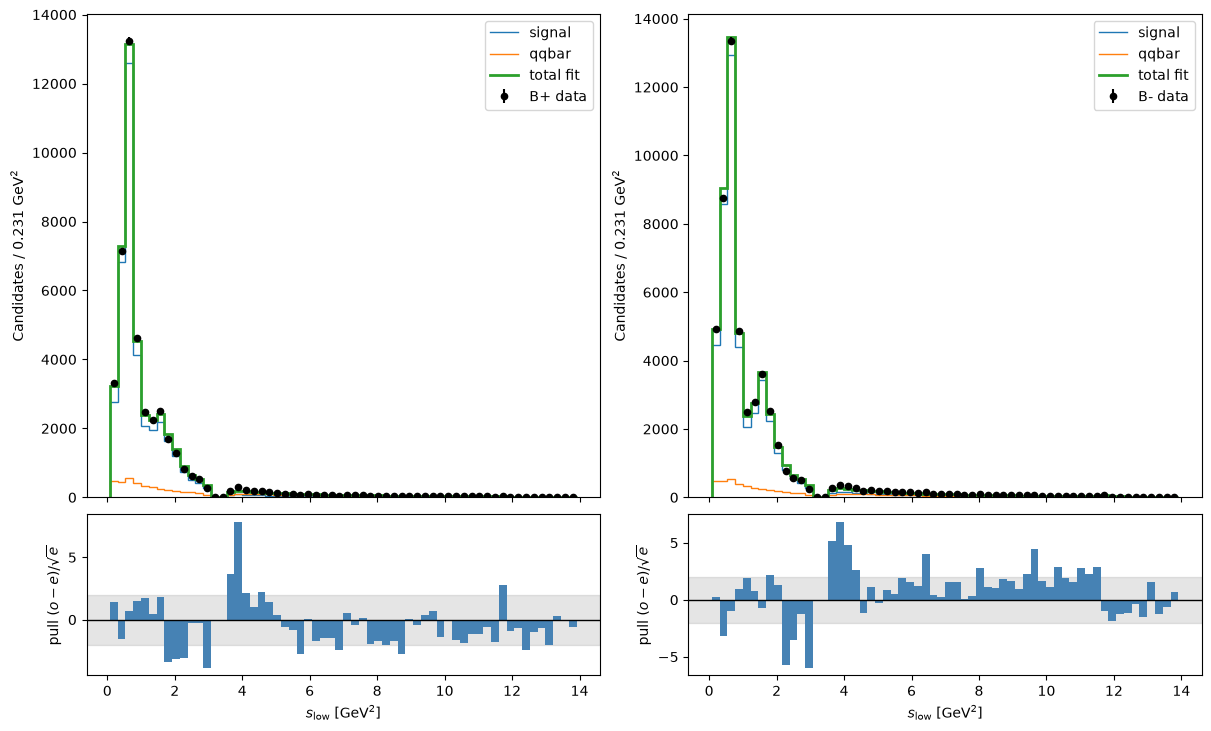

In [44]:
isobar_session.plot_projection(
    isobar_result, variable="s13", partner_variable="s23", folded=True,
    fold_side="low", bins=60, show_components=True, show_pulls=True,
    projection_size=1_000_000,
)
plt.show()


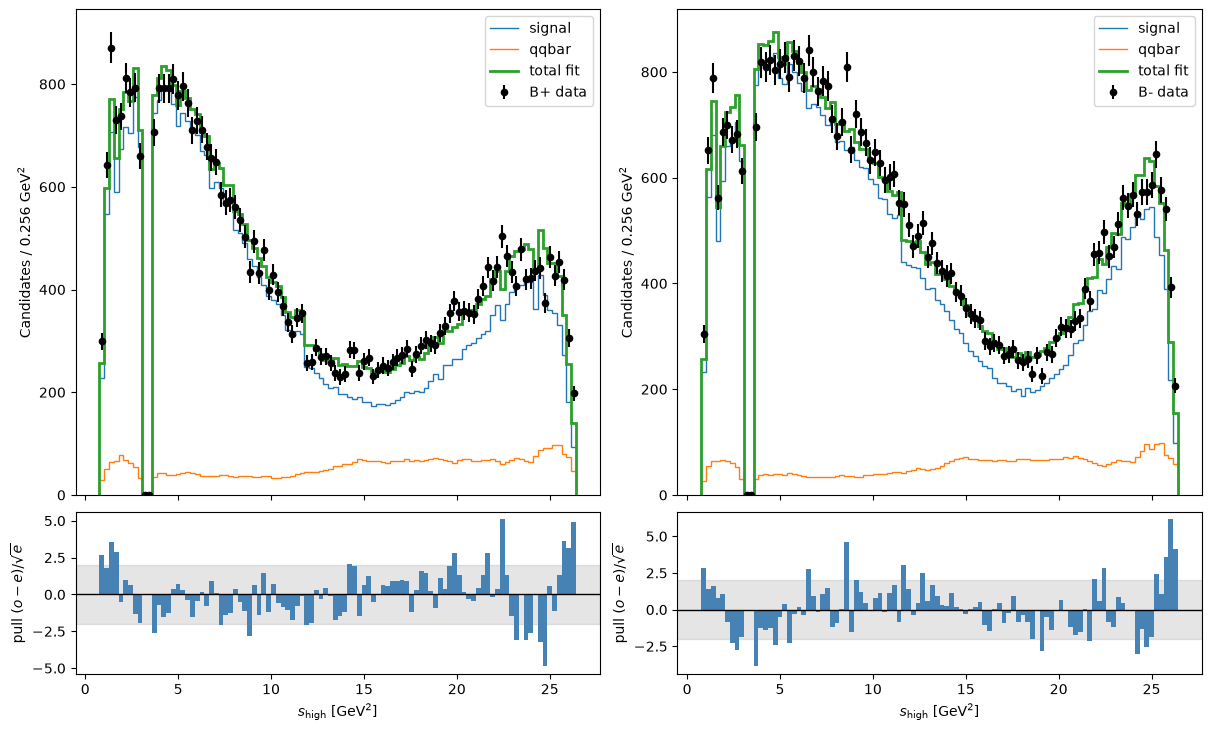

In [45]:
isobar_session.plot_projection(
    isobar_result, variable="s13", partner_variable="s23", folded=True,
    fold_side="high", bins=100, show_components=True, show_pulls=True,
    projection_size=1_000_000,
)
plt.show()


## Inicialização QMI a partir do resultado isobárico


In [46]:
def isobar_swave_single_pair(charge, mass):
    """Soma de um par, sem escalas individuais, com parâmetros do fit aos dados."""
    total = jnp.zeros_like(jnp.asarray(mass), dtype=jnp.complex128)
    for component in isobar_models[charge].amplitude_model.components:
        if component.name not in SWAVE_NAMES:
            continue
        dynamics = component.function
        total = total + component.coefficient.value(isobar_values) * dynamics.lineshape(
            jnp.asarray(mass), dynamics.context.resolve(isobar_values)
        )
    return np.asarray(total)


# QMI S-wave knots in m(pi+pi-), pair (2, 0) -- fixed list given for this fit.
QMI_KNOTS_GEV = (
    0.279140, 0.509015, 0.634185, 0.704998, 0.769832, 0.841871, 0.901300, 0.970000,
    0.980000, 0.990000, 1.000000, 1.070000, 1.133000, 1.195000, 1.250000, 1.310000,
    1.360000, 1.410000, 1.556780, 1.740000, 1.894000, 2.236000, 2.500000, 4.472131,
    4.817487, 5.139690,
)
# Constant amplitudes on the 25 reference mass intervals.
QMI_INTERPOLATION = "none"
QMI_SMOOTHNESS_STRENGTH = 0.0
QMI_BIN_CENTERS = (np.asarray(QMI_KNOTS_GEV[:-1]) + np.asarray(QMI_KNOTS_GEV[1:])) / 2
QMI_VETO_BINS = tuple(
    i for i, (lo, hi) in enumerate(zip(QMI_KNOTS_GEV[:-1], QMI_KNOTS_GEV[1:]))
    if lo >= D0_VETO_MIN_GEV and hi <= D0_VETO_MAX_GEV
)

_qmi_seed_amplitude = {
    charge: isobar_swave_single_pair(charge, QMI_BIN_CENTERS) for charge in (+1, -1)
}


def make_qmi_lineshape(charge, charge_label):
    """All bins outside the veto float; the external coefficient is fixed at 1+0j.

    Cartesian (real/imaginary) nodes are used instead of polar (magnitude/phase):
    docs/lineshapes.md notes that polar QMI coordinates can become poorly conditioned
    in a fit -- exactly the symptom seen here (huge covariance, high EDM, invalid
    result). Cartesian nodes also remove the magnitude-near-zero/undefined-phase
    direction that polar nodes can develop.
    """
    seed = _qmi_seed_amplitude[charge].copy()
    seed[list(QMI_VETO_BINS)] = 0.0 + 0.0j
    real_parts = tuple(
        Parameter.dynamics(
            f"S_QMI.{charge_label}.re_{i:02d}", float(value.real), owner="S_QMI", fixed=(i in QMI_VETO_BINS),
            step=max(1e-5, 0.02 * float(abs(value))),
        )
        for i, value in enumerate(seed)
    )
    imaginary_parts = tuple(
        Parameter.dynamics(
            f"S_QMI.{charge_label}.im_{i:02d}", float(value.imag), owner="S_QMI", fixed=(i in QMI_VETO_BINS),
            step=max(1e-5, 0.02 * float(abs(value))),
        )
        for i, value in enumerate(seed)
    )
    return QMI(knots=QMI_KNOTS_GEV, real_parts=real_parts, imaginary_parts=imaginary_parts,
               interpolation=QMI_INTERPOLATION)


S_QMI_LINESHAPES = {+1: make_qmi_lineshape(+1, "plus"), -1: make_qmi_lineshape(-1, "minus")}
shared_coefficients = make_shared_coefficients(isobar_values)
dynamics_parameters = make_dynamics_parameters(isobar_values)
print(f"Independent QMI: {len(QMI_BIN_CENTERS)} bins, {4 * (len(QMI_BIN_CENTERS) - len(QMI_VETO_BINS))} free parameters")

Independent QMI: 25 bins, 96 free parameters


## Onda-S de start (antes do ajuste)

Magnitude ao quadrado e fase da QMI inicial para B+ e B−, sem chi_c0, avaliadas
em uma única massa de par. Os pontos marcam os centros dos bins livres, incluindo o primeiro;
a faixa sombreada indica o veto D0. A fase é relativa ao rho de cada carga.
As duas cargas começam de sementes distintas (mesma assimetria CP `dx, dy` do fit isobárico),
com parâmetros independentes.
Esta célula usa os valores iniciais dos parâmetros e a avaliação constante por bin;
não depende de `result` nem dos valores pós-fit.


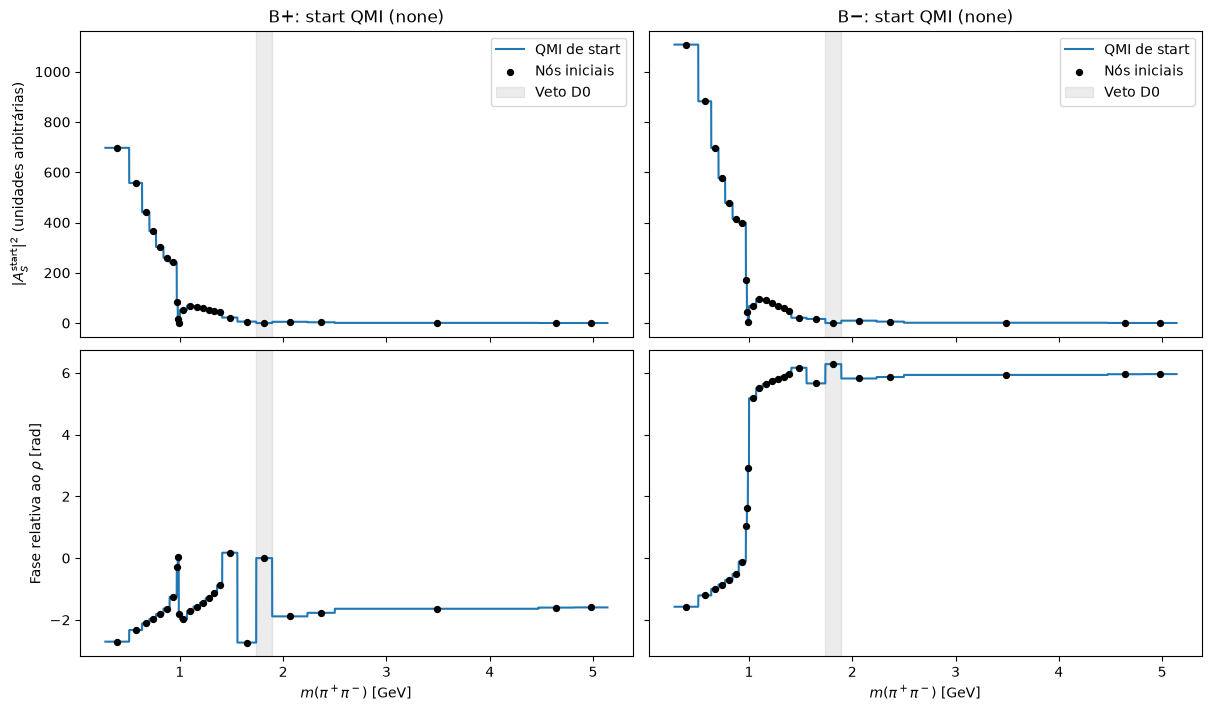

In [47]:
start_mass_scan = np.linspace(QMI_KNOTS_GEV[0], QMI_KNOTS_GEV[-1], 4000)
start_swave_curves = {}
fig_start_swave, start_axes = plt.subplots(
    2, 2, figsize=(12, 7), sharex=True, sharey="row", constrained_layout=True,
)

for col, (charge, charge_label) in enumerate(((+1, "B+"), (-1, "B−"))):
    qmi_parameters = S_QMI_LINESHAPES[charge]
    start_real = np.asarray([p.value for p in qmi_parameters.real_parts])
    start_imag = np.asarray([p.value for p in qmi_parameters.imaginary_parts])
    start_qmi = QMI(
        knots=qmi_parameters.knots,
        real_parts=tuple(start_real), imaginary_parts=tuple(start_imag),
        interpolation=qmi_parameters.interpolation,
    )
    start_magnitude, start_phase = start_qmi.interpolated_magnitude_phase(jnp.asarray(start_mass_scan))
    reference_phase = float(jnp.angle(shared_coefficients["rho0_770"].for_charge(charge).value({})))
    # Cartesian nodes make interpolated_magnitude_phase recompute jnp.angle(re + i*im) at
    # every scan point, wrapped to (-pi, pi]; unwrap so the plotted curve stays continuous
    # instead of showing spurious ~2*pi jumps wherever the physical phase crosses the cut.
    start_phase = np.unwrap(np.asarray(start_phase)) - reference_phase
    start_intensity = np.asarray(start_magnitude) ** 2  # fixed external coefficient: 1+0j
    start_swave_curves[charge_label] = {
        "mass_GeV": start_mass_scan, "intensity": start_intensity, "phase_rad": start_phase,
    }
    start_node_intensity = start_real ** 2 + start_imag ** 2
    # Unwrap across knots (increasing mass order) so markers land on the unwrapped curve
    # above instead of off it by a multiple of 2*pi at whichever knot the wrap cut falls on.
    start_node_phase = np.unwrap(np.angle(start_real + 1j * start_imag)) - reference_phase

    start_axes[0, col].plot(start_mass_scan, start_intensity, label="QMI de start")
    start_axes[0, col].scatter(QMI_BIN_CENTERS, start_node_intensity,
                               s=18, color="black", zorder=3, label="Nós iniciais")
    start_axes[1, col].plot(start_mass_scan, start_phase)
    start_axes[1, col].scatter(QMI_BIN_CENTERS, start_node_phase,
                               s=18, color="black", zorder=3)
    for row in (0, 1):
        start_axes[row, col].axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV,
                                    color="grey", alpha=0.15, label="Veto D0")
    start_axes[0, col].set_title(f"{charge_label}: start QMI ({qmi_parameters.interpolation})")
    start_axes[0, col].legend()
    start_axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")

start_axes[0, 0].set_ylabel(r"$|A_S^{\mathrm{start}}|^2$ (unidades arbitrárias)")
start_axes[1, 0].set_ylabel(r"Fase relativa ao $\rho$ [rad]")
plt.show()


## Componentes do modelo QMI

Os seis isóbaros restantes e `S_QMI` usam `normalize_component=False`; ambos os
modelos usam `normalize_components=False`, assim como no fit isobárico anterior.
O coeficiente externo da QMI é `1+0j`; a escala e a fase estão nos nós por carga.
A densidade total continua normalizada conjuntamente para B+ e B−, incluindo interferências.


In [48]:
def build_components(charge, shared, dynamics):
    coefficient = {name: cp.for_charge(charge) for name, cp in shared.items()}
    components = [
        Resonance(
            name, RESONANCE_PAIR, coefficient[name],
            lineshape=LINESHAPES[name](), angular=ZemachP(),
            normalize_component=False,
            mass=dynamics[f"{name}.mass"], width=dynamics[f"{name}.width"], spin=SPINS[name],
            resonance_radius=4.0, parent_radius=4.0,
        )
        for name in LINESHAPES if name not in SWAVE_NAMES
    ]
    components.append(
        Resonance(
            "S_QMI", RESONANCE_PAIR, RealImag(1.0, 0.0),
            lineshape=S_QMI_LINESHAPES[charge], angular=ZemachP(),
            normalize_component=False,
            mass=1.0, width=0.0, spin=0,
            resonance_radius=4.0, parent_radius=4.0,
        )
    )
    return components


plus_model = DecayModel(
    PLUS_CHANNEL, build_components(+1, shared_coefficients, dynamics_parameters),
    normalize_components=False,
    **NORMALIZATION_CONFIG
)
minus_model = DecayModel(
    MINUS_CHANNEL, build_components(-1, shared_coefficients, dynamics_parameters),
    normalize_components=False,
    **NORMALIZATION_CONFIG
)

print("B+ components:", [c.name for c in plus_model.amplitude_model.components])
print("B+ normalization sample size:", plus_model.normalization_sample.size)

B+ components: ['rho0_770', 'omega_782', 'rho0_1450', 'f2_1270', 'rho0_3_1690', 'chi_c0', 'S_QMI']
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=3.414710 GeV, Gamma=13.100 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=3.414710 GeV, Gamma=13.100 MeV); applying adaptive Square-Dalitz refinement only along the mass axis m'. Grid: 2936 m' nodes x 500 theta' nodes (1,468,000 points; base 250,000).
INFO DalitzPlotFitter normalization: crossed narrow band(s) are kept on the standard theta' resolution; only resonances aligned with normalization_pair refine m'.
B+ normalization sample size: 1468000


## Backgrounds nos dois ajustes

`make_data_fit_session` usa a quadratura de cada modelo para normalizar os
backgrounds pós-veto e aplicar as assimetrias fixas. Os dois fits usam os mesmos yields.


A sessão QMI abaixo reutiliza a mesma configuração experimental do fit isobárico.


In [49]:
# Backgrounds configurados por make_data_fit_session na célula seguinte.


## Sessão de ajuste CP

Ajuste estendido: `signal_yield` = `N_signal` fixo (o `signalAsym` do Laura++ não entra na
verossimilhança porque o DP está no ajuste, ver acima), background `qqbar` com yield total fixo e
a assimetria embutida nas formas `plus`/`minus` construídas acima. `kpipibkg` também é registrado,
com `yield_=0` fixo (inerte, ver acima).

In [50]:
fit_session = make_data_fit_session(plus_model, minus_model)
# One penalty per independent QMI shape (docs/lineshapes.md, "For CP QMI with
# independent charge shapes, attach one penalty for each"); QMI_SMOOTHNESS_STRENGTH=0.0
# would make both an exact no-op.
fit_session = fit_session.with_constraint(
    S_QMI_LINESHAPES[+1].smoothness_constraint(strength=QMI_SMOOTHNESS_STRENGTH)
)
fit_session = fit_session.with_constraint(
    S_QMI_LINESHAPES[-1].smoothness_constraint(strength=QMI_SMOOTHNESS_STRENGTH)
)

n_free = sum(1 for p in fit_session.parameters if not p.fixed)
n_fixed = sum(1 for p in fit_session.parameters if p.fixed)
print(f"parameters: {len(fit_session.parameters)} total, {n_free} free, {n_fixed} fixed")
print("S_QMI: 25 constant bins (re+im) per charge; D0-veto bin fixed at zero; external coefficients fixed")
print(f"QMI smoothness strength: {QMI_SMOOTHNESS_STRENGTH} (unvalidated -- see cell above)")
assert n_free == 4 * (len(QMI_BIN_CENTERS) - len(QMI_VETO_BINS)) + 21  # QMI + isobar coefficients

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=3.414710 GeV, Gamma=13.100 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=3.414710 GeV, Gamma=13.100 MeV); applying adaptive Square-Dalitz refinement only along the mass axis m'. Grid: 2936 m' nodes x 500 theta' nodes (1,468,000 points; base 250,000).
INFO DalitzPlotFitter normalization: crossed narrow band(s) are kept on the standard theta' resolution; only resonances aligned with normalization_pair refine m'.
parameters: 139 total, 117 free, 22 fixed
S_QMI: 25 constant bins (re+im) per charge; D0-veto bin fixed at zero; external coefficients fixed
QMI smoothness strength: 0.0 (unvalidated -- see cell above)


In [51]:
for p in fit_session.parameters:
    print(f"{p.name:24s} value={p.value: .6g}  fixed={p.fixed}")


rho0_770.x               value= 1  fixed=True
rho0_770.y               value= 0  fixed=True
rho0_770.dx              value= 0.000887211  fixed=False
rho0_770.dy              value= 0  fixed=True
rho0_770.mass            value= 0.770229  fixed=True
rho0_770.width           value= 0.148864  fixed=True
omega_782.x              value=-0.00793557  fixed=False
omega_782.y              value= 0.024719  fixed=False
omega_782.dx             value= 0.00185893  fixed=False
omega_782.dy             value= 0.00361723  fixed=False
omega_782.mass           value= 0.78265  fixed=True
omega_782.width          value= 0.00849  fixed=True
rho0_1450.x              value=-0.608837  fixed=False
rho0_1450.y              value= 0.253839  fixed=False
rho0_1450.dx             value=-0.203774  fixed=False
rho0_1450.dy             value=-0.0176926  fixed=False
rho0_1450.mass           value= 1.465  fixed=True
rho0_1450.width          value= 0.4  fixed=True
f2_1270.x                value= 0.0779036  fixed=False
f2_

## Ajuste QMI

O fit isobárico aos dados inicializa os coeficientes preservados e os nós QMI.
MIGRAD usa estratégia 1 e HESSE com Hessiana JAX. Verificamos a convergência e
a covariância antes dos diagnósticos. Múltiplos starts ainda podem explorar outros mínimos.


In [52]:
result = fit_session.fit(strategy=1, verbose=3, hesse=True, hessian="jax")
print(result.fmin)
if not result.valid or result.covariance is None or not result.fmin.has_accurate_covar:
    raise RuntimeError("Fit/covariance not reliable: inspect MIGRAD, EDM and HESSE before reporting errors")

[Minimizer] single fit with 117 free parameters (method=minuit, simplex=False, strategy=1, hesse=True, hessian=jax, ncall=None, tolerance=0.0001)
[Minimizer] MIGRAD 1 started
I MnSeedGenerator Computing seed using analytical (external) gradients and Hessian calculator


/Users/juanleite/Work/DalitzPlotFitter/.venv/lib/python3.13/site-packages/iminuit/minuit.py:733: IMinuitWarning: hessian overrides g2, passing g2 has no effect
  warnings.warn(


I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
I NegativeG2LineSearch Done after 1 min 17.1709 s
I MnSeedGenerator Initial seeding state  
  Minimum value : -491369.0296
  Edm           : 627.5007128
  Internal parameters:	[  0.0008872124255  -0.007935571098    0.02471899886   0.001858925942   0.003617229262    -0.6088366845     0.2538394799      -0.20377429   -0.01769263888    0.07790364145....     -0.1749990807]	
  Internal gradient  :	[       166.445516     -1124.991364     -718.7640881      154.2322795     -49.15370601     -21.11211131     -47.19636028     -13.62672723      128.3369012     -746.7128496....      -29.33945857]	
  Internal covariance matrix:
[[  1.3895901e-05              0              0              0              0              0              0              0              0              0....               0]
 [              0  1.8479763e-06              0              0              0              0              0    

In [53]:
values = fit_session.print_result(result)


valid=True  NLL=-492014.176339
parameter                           value            error
rho0_770.x                              1                0
rho0_770.y                              0                0
rho0_770.dx                    -0.0103409       0.00513893
rho0_770.dy                             0                0
rho0_770.mass                    0.770229                0
rho0_770.width                   0.148864                0
omega_782.x                    -0.0074215       0.00111767
omega_782.y                     0.0253186       0.00100943
omega_782.dx                   0.00202382       0.00113215
omega_782.dy                   0.00257989      0.000993731
omega_782.mass                    0.78265                0
omega_782.width                   0.00849                0
rho0_1450.x                     -0.561385         0.022896
rho0_1450.y                       0.40171        0.0196836
rho0_1450.dx                     -0.11331        0.0237981
rho0_1450.dy             

## Referência isobárica local

Os parâmetros do log Laura++ abaixo pertencem a outro modelo de onda-S. A tabela é apenas
uma referência dos valores isobáricos; não é um teste de pull ou de fechamento QMI.
Os dois fits usam os mesmos dados, portanto suas estimativas também são correlacionadas.

In [54]:
LAURA_FINAL = {
    "rho0_770.x": (1.00000e+00, 0.0), "rho0_770.y": (0.00000e+00, 0.0),
    "rho0_770.dx": (1.02312e-03, 3.60608e-03), "rho0_770.dy": (0.00000e+00, 0.0),
    "omega_782.x": (-3.03268e-02, 4.34944e-03), "omega_782.y": (9.48849e-02, 4.14539e-03),
    "omega_782.dx": (7.29877e-03, 4.07079e-03), "omega_782.dy": (1.38260e-02, 3.60962e-03),
    "rho0_1450.x": (-2.70865e-01, 6.46501e-03), "rho0_1450.y": (1.13529e-01, 5.70862e-03),
    "rho0_1450.dx": (-9.16491e-02, 6.14297e-03), "rho0_1450.dy": (-7.71941e-03, 5.37036e-03),
    "f2_1270.x": (3.51291e-01, 5.34772e-03), "f2_1270.y": (1.71931e-01, 5.93363e-03),
    "f2_1270.dx": (-5.45892e-02, 4.56093e-03), "f2_1270.dy": (-1.17944e-01, 5.02792e-03),
    "rho0_3_1690.x": (9.64994e-02, 3.98479e-03), "rho0_3_1690.y": (1.91968e-02, 5.36046e-03),
    "rho0_3_1690.dx": (4.92371e-02, 3.92311e-03), "rho0_3_1690.dy": (5.41424e-02, 5.23042e-03),
    "sigma0.x": (-4.02003e-01, 8.67937e-03), "sigma0.y": (3.57099e-01, 8.00027e-03),
    "sigma0.dx": (2.86690e-01, 5.95293e-03), "sigma0.dy": (2.01322e-01, 7.59760e-03),
    "f0_980.x": (1.41060e-01, 4.21299e-03), "f0_980.y": (-1.40500e-02, 5.84319e-03),
    "f0_980.dx": (-4.50930e-02, 4.83089e-03), "f0_980.dy": (-7.70899e-02, 3.92358e-03),
    "chi_c0.x": (2.71432e-02, 4.79001e-03), "chi_c0.y": (1.41733e-02, 5.83786e-03),
    "chi_c0.dx": (-4.02037e-02, 4.84198e-03), "chi_c0.dy": (-4.02666e-02, 5.88143e-03),
    "f0_1370.x": (1.00608e-01, 4.83099e-03), "f0_1370.y": (-2.34739e-02, 7.37598e-03),
    "f0_1370.dx": (5.11699e-02, 5.95883e-03), "f0_1370.dy": (-5.63136e-02, 4.65568e-03),
    "rho0_770.mass": (7.70229e-01, 5.99753e-04), "rho0_770.width": (1.48864e-01, 1.44233e-03),
    "f2_1270.mass": (1.25071e+00, 1.43721e-03), "f2_1270.width": (1.70502e-01, 3.35104e-03),
    "sigma0.mass": (5.09084e-01, 6.99672e-03), "sigma0.width": (4.25813e-01, 8.89256e-03),
    "f0_980.mass": (9.76535e-01, 1.07026e-03), "f0_980.width": (4.77831e-02, 2.61757e-03),
    "f0_1370.mass": (1.50218e+00, 6.70858e-03), "f0_1370.width": (1.73547e-01, 1.35102e-02),
}

rows = []
for p in fit_session.parameters:
    if p.name not in LAURA_FINAL:
        continue
    laura_value, laura_error = LAURA_FINAL[p.name]
    our_value = values[p.name]
    our_error = 0.0 if p.fixed else float(result.errors[p.name])
    rows.append({
        "parameter": p.name,
        "fixed": p.fixed,
        "our value": our_value,
        "our error": our_error,
        "Laura value": laura_value,
        "Laura error": laura_error,
        "difference (not a pull)": our_value - laura_value,
    })

comparison = pd.DataFrame(rows).set_index("parameter")
pd.set_option("display.float_format", lambda x: f"{x: .6g}")
comparison

,fixed,our value,our error,Laura value,Laura error,difference (not a pull)
parameter,,,,,,
rho0_770.x,True,1,0,1,0,0
rho0_770.y,True,0,0,0,0,0
rho0_770.dx,False,-0.0103409,0.00513893,0.00102312,0.00360608,-0.011364
rho0_770.dy,True,0,0,0,0,0
rho0_770.mass,True,0.770229,0,0.770229,0.000599753,0
rho0_770.width,True,0.148864,0,0.148864,0.00144233,0
omega_782.x,False,-0.0074215,0.00111767,-0.0303268,0.00434944,0.0229053
omega_782.y,False,0.0253186,0.00100943,0.0948849,0.00414539,-0.0695663
omega_782.dx,False,0.00202382,0.00113215,0.00729877,0.00407079,-0.00527495


## Fit fractions físicas por carga

Integrais no DP completo, sem eficiência/veto, com `integral(f)=mean(weights*f)`.
A FF da onda-S é a da amplitude QMI simetrizada, sem chi_c0. Comparar com uma soma
isobárica exige incluir suas interferências. A FF CP média é ponderada pelas taxas R±.

In [55]:
component_names = [c.name for c in plus_model.amplitude_model.components]
# Physical caches exclude efficiency/veto; accepted charge fractions must not replace these rates.
physical_caches = {
    charge: model.prepare_cache(model.normalization_sample.take(jnp.arange(1)))
    for charge, model in (("plus", plus_model), ("minus", minus_model))
}


def physical_component_rates(cache, fit_values):
    matrix = cache.normalization_matrix(fit_values)
    coefficients = cache.coefficient_vector(fit_values)
    rates = jnp.abs(coefficients) ** 2 * jnp.real(jnp.diag(matrix))
    total = jnp.real(jnp.vdot(coefficients, matrix @ coefficients))
    return rates, total


physical_rates = {q: physical_component_rates(cache, values) for q, cache in physical_caches.items()}
fit_fractions = {
    q: dict(zip(component_names, map(float, rates / total)))
    for q, (rates, total) in physical_rates.items()
}
physical_ff_cp = dict(zip(component_names, map(float,
    (physical_rates["plus"][0] + physical_rates["minus"][0])
    / (physical_rates["plus"][1] + physical_rates["minus"][1]))))
print("R_plus =", float(physical_rates["plus"][1]), "R_minus =", float(physical_rates["minus"][1]))
display(pd.DataFrame(fit_fractions) * 100.0)

R_plus = 141004.0436968817 R_minus = 166251.71466354153


,plus,minus
rho0_770,61.1218,54.0289
omega_782,0.741656,0.472289
rho0_1450,9.04623,2.97911
f2_1270,6.35173,12.8749
rho0_3_1690,1.25222,0.297348
chi_c0,0.105709,0.448152
S_QMI,20.2565,25.2767


In [56]:
def _ff_asymmetry_percent(plus_ff, minus_ff):
    return {
        name: 100.0 * (minus_ff[name] - plus_ff[name]) / (minus_ff[name] + plus_ff[name])
        for name in plus_ff
    }


component_names = [c.name for c in plus_model.amplitude_model.components]
plus_ff_pct = {n: 100.0 * fit_fractions["plus"][n] for n in component_names}
minus_ff_pct = {n: 100.0 * fit_fractions["minus"][n] for n in component_names}

our_table = pd.DataFrame({
    "B- FF [%]": minus_ff_pct,
    "B+ FF [%]": plus_ff_pct,
    "FF asym [%]": _ff_asymmetry_percent(plus_ff_pct, minus_ff_pct),
})
our_table


,B- FF [%],B+ FF [%],FF asym [%]
rho0_770,54.0289,61.1218,-6.15966
omega_782,0.472289,0.741656,-22.1894
rho0_1450,2.97911,9.04623,-50.4528
f2_1270,12.8749,6.35173,33.9279
rho0_3_1690,0.297348,1.25222,-61.622
chi_c0,0.448152,0.105709,61.8284
S_QMI,25.2767,20.2565,11.0254


### ACP integrado por componente

`ACP = (I_minus - I_plus)/(I_minus + I_plus)`, com as integrais físicas de cada
componente. Para a QMI independente, entram os nós de ambas as cargas. A incerteza
propaga a covariância conjunta de todos os parâmetros livres, incluindo dinâmica.

In [57]:
def component_acp_percent(fit_values):
    plus_rates, _ = physical_component_rates(physical_caches["plus"], fit_values)
    minus_rates, _ = physical_component_rates(physical_caches["minus"], fit_values)
    return 100.0 * (minus_rates - plus_rates) / (minus_rates + plus_rates)


free_parameter_names = [p.name for p in fit_session.parameters if not p.fixed]
acp_errors = delta_method_errors(component_acp_percent, values, free_parameter_names, result.covariance)
acp_table = pd.DataFrame({
    "ACP [%]": np.asarray(component_acp_percent(values)),
    "sigma(ACP)": np.asarray(acp_errors),
}, index=component_names)
display(acp_table)
# These extra caches are only needed for physical observable derivatives, not fit evaluation.
del physical_caches

,ACP [%],sigma(ACP)
rho0_770,2.06796,1.02746
omega_782,-14.2317,7.86593
rho0_1450,-44.0624,3.9501
f2_1270,41.0019,2.1981
rho0_3_1690,-56.2532,6.59118
chi_c0,66.6589,6.84846
S_QMI,19.0698,1.37582


## Comparação com a tabela fornecida: coeficientes globais (NLL 967471)

Os valores de `A_i` são tratados como **magnitudes dos coeficientes globais**,
conforme esclarecido pelo usuário: não aplicamos quadrado, raiz ou fator `10⁻²`
a essas colunas, apesar do cabeçalho da imagem. Esta tabela é distinta das tabelas
do draft apresentadas a seguir. A tabela de onda-S por bin também permanece separada.

Comparamos FF por carga, FF média e ACP integrado, além de magnitude e fase dos seis
coeficientes isobáricos (fase relativa ao rho). Exibimos tanto a FF média aritmética
quanto a ponderada pelas taxas, pois a imagem não define `<FF>` explicitamente.
As magnitudes são coeficientes da nossa base **sem normalização individual**; sua
comparação direta pressupõe a mesma convenção de escala das funções na referência.

No nosso QMI independente por carga, `c_S=1+0j` é fixo e os nós carregam toda a
escala/fase. Logo, não há um coeficiente global de onda-S ajustado para comparar
com `2.35 exp(-85i°)` / `1.55 exp(-80i°)` sem definir a normalização e a fase da
forma QMI da referência. A linha S-wave entra nas comparações de FF e ACP;
as colunas do coeficiente ajustado ficam ausentes nessa linha, não recebem 1 como
se fosse uma estimativa física. Os gráficos de coeficientes incluem os seis isóbaros.
Não calculamos pulls entre fits nem comparamos NLLs sem confirmar as convenções.


,FF B+ nosso [%],FF B+ tabela [%],FF B- nosso [%],FF B- tabela [%],FF média aritmética nosso [%],FF ponderada nosso [%],FF média tabela [%],ACP nosso [%],erro ACP nosso [%],ACP tabela [%],erro ACP tabela [%]
rho0_770,61.1218,61.7,54.0289,53.6,57.5753,57.2839,57.3,2.06796,1.02746,1.4,1.1
omega_782,0.741656,0.7,0.472289,0.5,0.606972,0.595905,0.6,-14.2317,7.86593,-12.7,7.9
rho0_1450,9.04623,7.1,2.97911,4,6.01267,5.7634,5.4,-44.0624,3.9501,-19.7,6.2
f2_1270,6.35173,6.3,12.8749,12.7,9.61332,9.88133,9.8,41.0019,2.1981,40.7,2.3
rho0_3_1690,1.25222,0.6,0.297348,0.2,0.774786,0.735554,0.4,-56.2532,6.59118,-37.8,9.7
chi_c0,0.105709,0.1,0.448152,0.4,0.276931,0.291,0.3,66.6589,6.84846,71,7.1
S_QMI,20.2565,20.4,25.2767,26.4,22.7666,22.9728,23.7,19.0698,1.37582,18.4,1.7


,nosso,tabela (soma impressa)
Soma FF ponderada/média [%],97.524,97.4
Soma FF B- [%],96.3774,97.9
Soma FF B+ [%],98.8758,96.9


magnitude nosso  magnitude tabela  erro magnitude tabela  \
component   charge                                                             
rho0_770    plus           0.989659              0.99                   0.01   
            minus           1.01034              1.01                   0.01   
omega_782   plus          0.0284159              0.03                      0   
            minus         0.0246224              0.02                      0   
rho0_1450   plus           0.851422              0.68                   0.03   
            minus          0.530544              0.56                   0.04   
f2_1270     plus           0.070873               0.8                   0.02   
            minus          0.109566              1.23                   0.03   
rho0_3_1690 plus         0.00671623              0.23                   0.01   
            minus        0.00355373              0.15                   0.02   
chi_c0      plus           0.256141                 0                      0   
            minus          0.572669                 0                      0   
S_QMI       plus                NaN              2.35                   0.05   
            minus               NaN              1.55                   0.05   

                    fase nosso [deg]  fase tabela [deg]  \
component   charge                                        
rho0_770    plus                   0                  0   
            minus                  0                  0   
omega_782   plus              100.95                102   
            minus            112.557                113   
rho0_1450   plus             142.414                129   
            minus            147.625                150   
f2_1270     plus             1.83835                  2   
            minus            34.2848                 42   
rho0_3_1690 plus             16.5145                  2   
            minus           -36.2045                -39   
chi_c0      plus            -81.1332                -68   
            minus             56.936                 70   
S_QMI       plus                 NaN                -85   
            minus                NaN                -80   

                    erro fase tabela [deg]  diferença fase [deg]  
component   charge                                                
rho0_770    plus                         0                     0  
            minus                        0                     0  
omega_782   plus                         3              -1.04996  
            minus                        4              -0.44277  
rho0_1450   plus                         3               13.4136  
            minus                        3              -2.37547  
f2_1270     plus                         3              -0.16165  
            minus                        2              -7.71516  
rho0_3_1690 plus                         8               14.5145  
            minus                       10               2.79548  
chi_c0      plus                        15              -13.1332  
            minus                        6               -13.064  
S_QMI       plus                         0                   NaN  
            minus                        0                   NaN

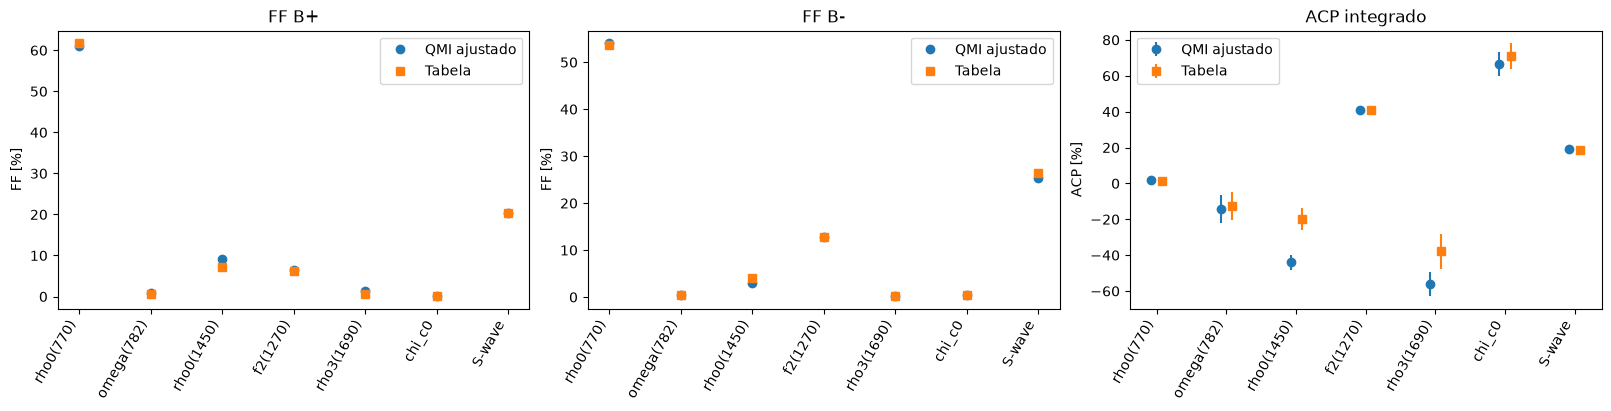

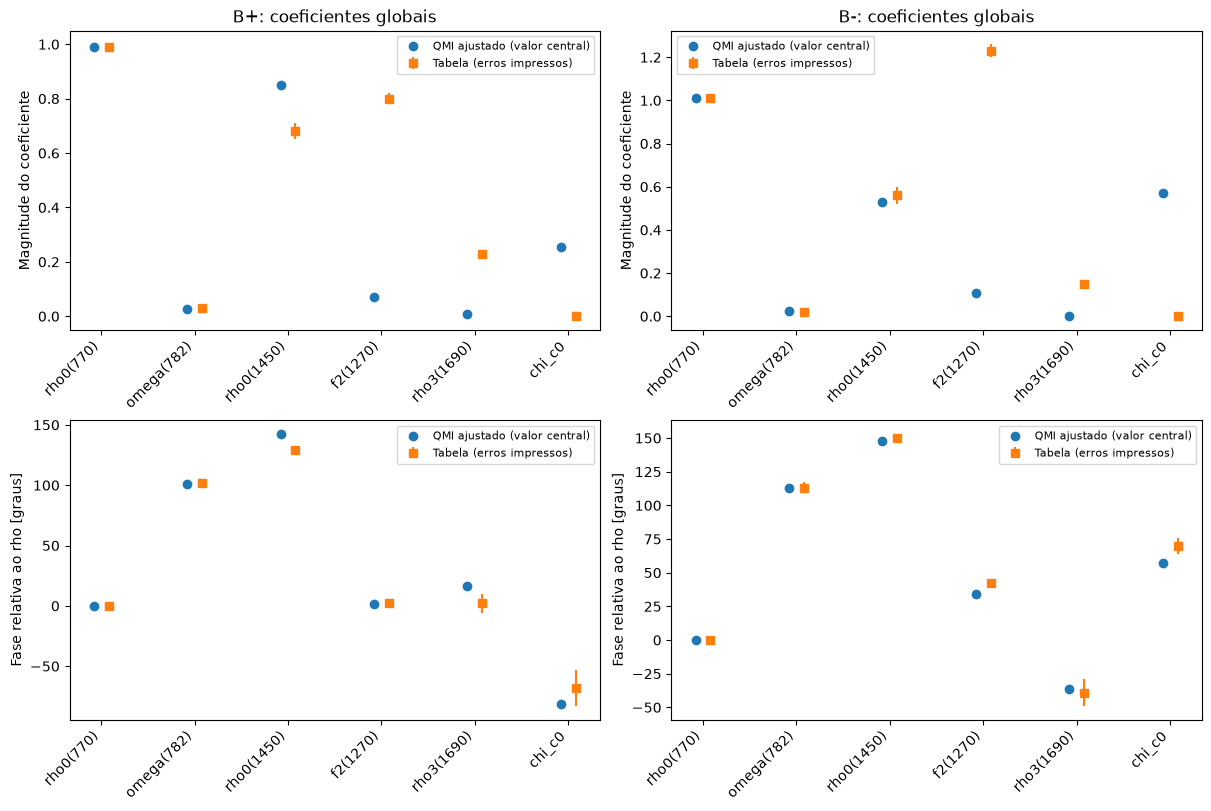

In [58]:
REFERENCE_TABLE_NAMES = {
    "rho0_770": "rho0(770)", "omega_782": "omega(782)", "rho0_1450": "rho0(1450)",
    "f2_1270": "f2(1270)", "rho0_3_1690": "rho3(1690)", "chi_c0": "chi_c0", "S_QMI": "S-wave",
}


def _wrap_deg(angle_deg):
    return (np.asarray(angle_deg) + 180.0) % 360.0 - 180.0


def coefficient_at(name, charge, fit_values):
    return shared_coefficients[name].for_charge(charge).value(fit_values)


# Transcrição da imagem; magnitudes interpretadas conforme esclarecimento do usuário.
# FF média, FF B-, FF B+, mag+, erro, fase+, erro, mag-, erro, fase-, erro, ACP, erro.
GLOBAL_REFERENCE = pd.DataFrame([
    [57.3, 53.6, 61.7, .99, .01, 0, 0, 1.01, .01, 0, 0, 1.4, 1.1],
    [0.6, 0.5, 0.7, .03, .00, 102, 3, .02, .00, 113, 4, -12.7, 7.9],
    [5.4, 4.0, 7.1, .68, .03, 129, 3, .56, .04, 150, 3, -19.7, 6.2],
    [9.8, 12.7, 6.3, .80, .02, 2, 3, 1.23, .03, 42, 2, 40.7, 2.3],
    [0.4, 0.2, 0.6, .23, .01, 2, 8, .15, .02, -39, 10, -37.8, 9.7],
    [0.3, 0.4, 0.1, .00, .00, -68, 15, .00, .00, 70, 6, 71.0, 7.1],
    [23.7, 26.4, 20.4, 2.35, .05, -85, 0, 1.55, .05, -80, 0, 18.4, 1.7],
], index=list(REFERENCE_TABLE_NAMES), columns=[
    "ff_average", "ff_minus", "ff_plus", "mag_plus", "mag_plus_error", "phase_plus", "phase_plus_error",
    "mag_minus", "mag_minus_error", "phase_minus", "phase_minus_error", "acp", "acp_error",
])
# Zeros de magnitude/erro são arredondados na imagem, não precisão infinita.
global_observable_comparison = pd.DataFrame({
    "FF B+ nosso [%]": plus_ff_pct, "FF B+ tabela [%]": GLOBAL_REFERENCE.ff_plus,
    "FF B- nosso [%]": minus_ff_pct, "FF B- tabela [%]": GLOBAL_REFERENCE.ff_minus,
    "FF média aritmética nosso [%]": {k: (plus_ff_pct[k] + minus_ff_pct[k]) / 2 for k in component_names},
    "FF ponderada nosso [%]": {k: 100 * physical_ff_cp[k] for k in component_names},
    "FF média tabela [%]": GLOBAL_REFERENCE.ff_average,
    "ACP nosso [%]": acp_table["ACP [%]"], "erro ACP nosso [%]": acp_table["sigma(ACP)"],
    "ACP tabela [%]": GLOBAL_REFERENCE.acp, "erro ACP tabela [%]": GLOBAL_REFERENCE.acp_error,
}).reindex(GLOBAL_REFERENCE.index)
display(global_observable_comparison)
display(pd.DataFrame({
    "nosso": [sum(physical_ff_cp.values()) * 100, sum(minus_ff_pct.values()), sum(plus_ff_pct.values())],
    "tabela (soma impressa)": [97.4, 97.9, 96.9],
}, index=["Soma FF ponderada/média [%]", "Soma FF B- [%]", "Soma FF B+ [%]"]))

coefficient_rows = []
for name in GLOBAL_REFERENCE.index:
    for charge, suffix in ((+1, "plus"), (-1, "minus")):
        mag = phase = np.nan
        if name != "S_QMI":
            coef = complex(coefficient_at(name, charge, values))
            rho = complex(coefficient_at("rho0_770", charge, values))
            mag = abs(coef)
            phase = float(_wrap_deg(np.degrees(np.angle(coef / rho))))
        ref = GLOBAL_REFERENCE.loc[name]
        coefficient_rows.append({
            "component": name, "charge": suffix, "magnitude nosso": mag,
            "magnitude tabela": ref[f"mag_{suffix}"], "erro magnitude tabela": ref[f"mag_{suffix}_error"],
            "fase nosso [deg]": phase, "fase tabela [deg]": ref[f"phase_{suffix}"],
            "erro fase tabela [deg]": ref[f"phase_{suffix}_error"],
            "diferença fase [deg]": float(_wrap_deg(phase - ref[f"phase_{suffix}"])),
        })
global_coefficient_comparison = pd.DataFrame(coefficient_rows).set_index(["component", "charge"])
display(global_coefficient_comparison)

names = list(GLOBAL_REFERENCE.index)
x = np.arange(len(names))
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for ax, suffix, ours in zip(axes[:2], ("plus", "minus"), (plus_ff_pct, minus_ff_pct)):
    ax.plot(x, [ours[k] for k in names], "o", label="QMI ajustado")
    ax.plot(x, GLOBAL_REFERENCE[f"ff_{suffix}"], "s", label="Tabela")
    ax.set_title(f"FF B{'+' if suffix == 'plus' else '-'}")
    ax.set_ylabel("FF [%]")
axes[2].errorbar(x - .08, acp_table.loc[names, "ACP [%]"], yerr=acp_table.loc[names, "sigma(ACP)"],
                 fmt="o", label="QMI ajustado")
axes[2].errorbar(x + .08, GLOBAL_REFERENCE.acp, yerr=GLOBAL_REFERENCE.acp_error, fmt="s", label="Tabela")
axes[2].set_title("ACP integrado")
axes[2].set_ylabel("ACP [%]")
for ax in axes:
    ax.set_xticks(x, [REFERENCE_TABLE_NAMES[k] for k in names], rotation=60, ha="right")
    ax.legend()
plt.show()

isobar_names = [k for k in names if k != "S_QMI"]
x = np.arange(len(isobar_names))
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for col, suffix in enumerate(("plus", "minus")):
    frame = global_coefficient_comparison.xs(suffix, level="charge").loc[isobar_names]
    for row, (our_col, ref_col, err_col, label) in enumerate((
        ("magnitude nosso", "magnitude tabela", "erro magnitude tabela", "Magnitude do coeficiente"),
        ("fase nosso [deg]", "fase tabela [deg]", "erro fase tabela [deg]", "Fase relativa ao rho [graus]"),
    )):
        ax = axes[row, col]
        ax.plot(x - .08, frame[our_col], "o", label="QMI ajustado (valor central)")
        ax.errorbar(x + .08, frame[ref_col], yerr=frame[err_col], fmt="s", label="Tabela (erros impressos)")
        ax.set_ylabel(label)
        ax.set_xticks(x, [REFERENCE_TABLE_NAMES[k] for k in isobar_names], rotation=45, ha="right")
        ax.legend(fontsize=8)
    axes[0, col].set_title(f"B{'+' if suffix == 'plus' else '-'}: coeficientes globais")
plt.show()


### Comparação com as tabelas do draft

A Tabela 9 é a referência para FF_CP e ACP, incluindo a onda-S integrada.
A Tabela 23 permite uma comparação exploratória das fases dos isóbaros relativas ao rho;
a linha agregada S-wave não define a curva QMI. As magnitudes dessa tabela e dos CSVs
não têm equivalência demonstrada com a convenção deste notebook e não são equiparadas.

In [59]:
# Tabela 9 ("QMI – Fit Fractions and ACP for QMI model 212-112") do rascunho
# amanr2pipipi_paper_draft.pdf -- FF em %, ACP em % com incerteza (só estatística, sem sistemática
# separada nessa tabela).
PAPER_TABLE9_QMI = {
    "rho0(770)":   dict(ff_percent=56.9, acp_percent=0.2,   acp_err_percent=1.3),
    "omega(782)":  dict(ff_percent=0.7,  acp_percent=-10.4, acp_err_percent=7.5),
    "rho0(1450)":  dict(ff_percent=6.2,  acp_percent=-28.9, acp_err_percent=4.9),
    "f2(1270)":    dict(ff_percent=9.8,  acp_percent=36.4,  acp_err_percent=2.3),
    "rho3(1690)":  dict(ff_percent=0.7,  acp_percent=-65.5, acp_err_percent=6.0),
    "chi_c0":      dict(ff_percent=0.3,  acp_percent=71.7,  acp_err_percent=7.3),
    "S-wave":      dict(ff_percent=23.6, acp_percent=21.3,  acp_err_percent=1.8),
}

# Table 23 ("QMI - magnitudes and phases extracted from the fit"), [NLL 529030] -- a_i^{+/-}
# Magnitudes are transcribed as printed; their mapping to our normalization is unverified.
PAPER_TABLE23_QMI = {
    "rho0(770)":  dict(a_plus=0.999, a_plus_err=0.007, delta_plus=0.000,    delta_plus_err=0.081,
                        a_minus=1.001, a_minus_err=0.007, delta_minus=0.000,   delta_minus_err=0.081),
    "omega(782)": dict(a_plus=0.027, a_plus_err=0.001, delta_plus=102.356,  delta_plus_err=3.102,
                        a_minus=0.024, a_minus_err=0.001, delta_minus=113.291, delta_minus_err=3.403),
    "rho0(1450)": dict(a_plus=0.755, a_plus_err=0.032, delta_plus=147.291,  delta_plus_err=2.421,
                        a_minus=0.561, a_minus_err=0.032, delta_minus=155.669, delta_minus_err=3.260),
    "f2(1270)":   dict(a_plus=0.836, a_plus_err=0.025, delta_plus=10.846,   delta_plus_err=2.559,
                        a_minus=1.224, a_minus_err=0.030, delta_minus=39.507,  delta_minus_err=1.538),
    "rho3(1690)": dict(a_plus=0.338, a_plus_err=0.019, delta_plus=34.341,   delta_plus_err=3.595,
                        a_minus=0.154, a_minus_err=0.018, delta_minus=-21.784, delta_minus_err=8.225),
    "chi_c0":     dict(a_plus=0.001, a_plus_err=0.000, delta_plus=-71.126,  delta_plus_err=13.963,
                        a_minus=0.004, a_minus_err=0.000, delta_minus=55.842,  delta_minus_err=5.408),
    "S-wave":     dict(a_plus=2.344, a_plus_err=0.055, delta_plus=-84.724,  delta_plus_err=0.155,
                        a_minus=1.483, a_minus_err=0.054, delta_minus=-79.602, delta_minus_err=0.410),
}

paper_rows = []
phase_rows = []
for name, ref in REFERENCE_TABLE_NAMES.items():
    paper = PAPER_TABLE9_QMI[ref]
    paper_rows.append({
        "component": name,
        "FF_CP [%] nosso": 100.0 * physical_ff_cp[name], "FF_CP [%] draft": paper["ff_percent"],
        "ACP [%] nosso": acp_table.loc[name, "ACP [%]"], "sigma(ACP) nosso": acp_table.loc[name, "sigma(ACP)"],
        "ACP [%] draft": paper["acp_percent"], "sigma(ACP) draft": paper["acp_err_percent"],
    })
    if name == "S_QMI":
        continue  # Independent shapes: no single S-wave phase represents all nodes.
    for charge, suffix in ((+1, "plus"), (-1, "minus")):
        our_phase = float(jnp.angle(coefficient_at(name, charge, values)
                                   / coefficient_at("rho0_770", charge, values)) * 180.0 / jnp.pi)
        ref_phase = PAPER_TABLE23_QMI[ref][f"delta_{suffix}"]
        phase_rows.append({"component": name, "charge": suffix,
                           "phase wrt rho [deg]": our_phase, "draft [deg]": ref_phase,
                           "difference [deg]": float(_wrap_deg(our_phase - ref_phase))})
paper_reference_comparison = pd.DataFrame(paper_rows).set_index("component")
display(paper_reference_comparison)
display(pd.DataFrame(phase_rows).set_index(["component", "charge"]))

,FF_CP [%] nosso,FF_CP [%] draft,ACP [%] nosso,sigma(ACP) nosso,ACP [%] draft,sigma(ACP) draft
component,,,,,,
rho0_770,57.2839,56.9,2.06796,1.02746,0.2,1.3
omega_782,0.595905,0.7,-14.2317,7.86593,-10.4,7.5
rho0_1450,5.7634,6.2,-44.0624,3.9501,-28.9,4.9
f2_1270,9.88133,9.8,41.0019,2.1981,36.4,2.3
rho0_3_1690,0.735554,0.7,-56.2532,6.59118,-65.5,6
chi_c0,0.291,0.3,66.6589,6.84846,71.7,7.3
S_QMI,22.9728,23.6,19.0698,1.37582,21.3,1.8


phase wrt rho [deg]  draft [deg]  difference [deg]
component   charge                                                    
rho0_770    plus                      0            0                 0
            minus                     0            0                 0
omega_782   plus                 100.95      102.356          -1.40596
            minus               112.557      113.291          -0.73377
rho0_1450   plus                142.414      147.291          -4.87744
            minus               147.625      155.669          -8.04447
f2_1270     plus                1.83835       10.846          -9.00765
            minus               34.2848       39.507          -5.22216
rho0_3_1690 plus                16.5145       34.341          -17.8265
            minus              -36.2045      -21.784          -14.4205
chi_c0      plus               -81.1332      -71.126          -10.0072
            minus                56.936       55.842             1.094

## Onda-S por carga: magnitude e fase, com e sem chi_c0

Curvas de um único par em função de m(pi+pi-), sem construir pontos artificiais do DP.
A QMI é avaliada diretamente nos seus nós ajustados. chi_c0 entra com sua lineshape
bruta e coeficiente, sem normalização individual, como no ajuste. A fase é relativa ao rho de cada carga.
Os eixos de magnitude têm a mesma escala em B+ e B−; a intensidade de uma única
lineshape não é uma projeção de contagens nem a integral física da onda-S.

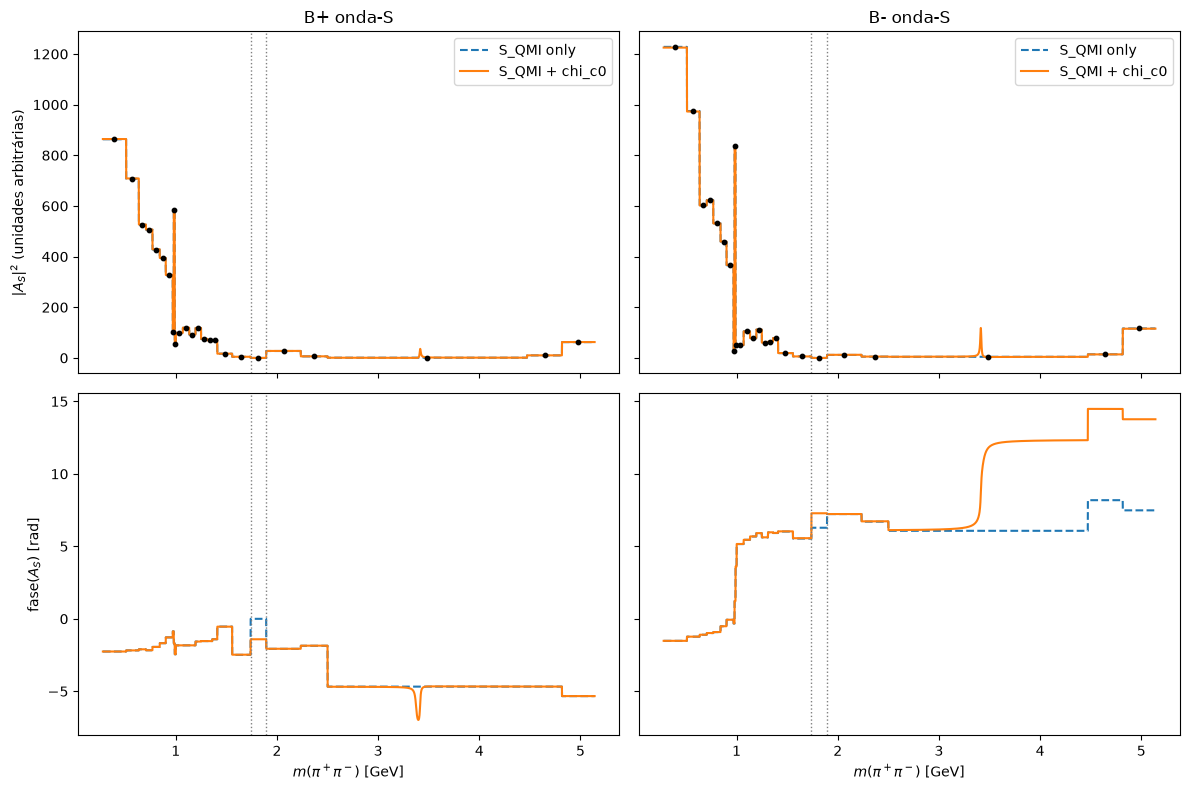

In [60]:
def swave_scan(model, values, mass_scan, *, include_chic0):
    charge = +1 if model is plus_model else -1
    label = "plus" if charge == +1 else "minus"
    real_parts = tuple(values[f"S_QMI.{label}.re_{i:02d}"] for i in range(len(QMI_BIN_CENTERS)))
    imaginary_parts = tuple(values[f"S_QMI.{label}.im_{i:02d}"] for i in range(len(QMI_BIN_CENTERS)))
    qmi = QMI(knots=QMI_KNOTS_GEV, real_parts=real_parts, imaginary_parts=imaginary_parts,
              interpolation=QMI_INTERPOLATION)
    mag, phase = qmi.interpolated_magnitude_phase(jnp.asarray(mass_scan))
    amplitude = mag * jnp.exp(1j * phase)
    if include_chic0:
        component = next(c for c in model.amplitude_model.components if c.name == "chi_c0")
        dynamics = component.function
        amplitude = amplitude + (coefficient_at("chi_c0", charge, values)
            * dynamics.lineshape(jnp.asarray(mass_scan), dynamics.context.resolve(values)))
    reference = coefficient_at("rho0_770", charge, values)
    return np.asarray(amplitude * jnp.exp(-1j * jnp.angle(reference)))


swave_mass_scan = np.linspace(QMI_KNOTS_GEV[0], QMI_KNOTS_GEV[-1], 4000)

swave_curves = {}
for charge_label, charge_model in (("B+", plus_model), ("B-", minus_model)):
    for include_chic0, tag in ((False, "S_QMI only"), (True, "S_QMI + chi_c0")):
        swave_curves[(charge_label, tag)] = swave_scan(
            charge_model, values, swave_mass_scan, include_chic0=include_chic0,
        )

qmi_only_knot_values = {
    charge_label: swave_scan(charge_model, values, QMI_BIN_CENTERS, include_chic0=False)
    for charge_label, charge_model in (("B+", plus_model), ("B-", minus_model))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey="row")
for col, charge_label in enumerate(("B+", "B-")):
    for tag, style in (("S_QMI only", "--"), ("S_QMI + chi_c0", "-")):
        amplitude = swave_curves[(charge_label, tag)]
        axes[0, col].plot(swave_mass_scan, np.abs(amplitude) ** 2, style, label=tag)
        axes[1, col].plot(swave_mass_scan, np.unwrap(np.angle(amplitude)), style, label=tag)

    axes[0, col].scatter(
        QMI_BIN_CENTERS, np.abs(qmi_only_knot_values[charge_label]) ** 2,
        s=10, color="black", zorder=3,
    )
    for mass in (D0_VETO_MIN_GEV, D0_VETO_MAX_GEV):
        axes[0, col].axvline(mass, color="grey", ls=":", lw=1)
        axes[1, col].axvline(mass, color="grey", ls=":", lw=1)

    axes[0, col].set_title(f"{charge_label} onda-S")
    axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
    axes[0, col].legend()

axes[0, 0].set_ylabel(r"$|A_S|^2$ (unidades arbitrárias)")
axes[1, 0].set_ylabel(r"fase$(A_S)$ [rad]")
fig.tight_layout()
plt.show()

### QMI ajustado versus tabela 203-112: SWave

Transcrição da imagem fornecida: 25 valores **por intervalo de massa** da Tabela 28,
não 25 nós com um extremo ausente. A referência é desenhada em escadinha: magnitude² e fase constantes dentro
de cada intervalo, com degraus nos limites dos bins. O bin 20 coincide com o veto D0; seus zeros não definem uma
fase física nem são usados como condição de contorno. A comparação exclui `chi_c0`.

Interpretamos o cabeçalho como `|A|² = valor impresso × 10⁻²`, configurável abaixo.
Como a imagem não especifica a normalização das amplitudes da referência,
`COMPARISON_MODE="shape"` compara a forma dividindo cada conjunto pela integral
em massa de `|A_plus|² + |A_minus|²`, fora do veto. É **uma única escala por conjunto**,
preservando a razão entre cargas; isso é apenas uma convenção de visualização,
não a integral física no Dalitz nem uma normalização dos componentes do fit.
`"absolute"` exibe os valores brutos e requer convenções de amplitude compatíveis.

Nossas fases são relativas ao rho. Os offsets explícitos da tabela são zero por
padrão, supondo a mesma referência; a imagem não confirma essa convenção. Não
ajustamos offsets automaticamente. Sem erros/covariâncias na tabela, a comparação
é visual, sem significâncias. Os valores do fit nos centros são avaliações da curva,
não médias de bin nem parâmetros de um novo fit binado.

Nossa onda-S também é mostrada em escadinha, com magnitude² e fase avaliadas
no centro de cada intervalo e mantidas constantes até suas bordas. Isso altera
apenas a visualização; a avaliação constante por bin do fit e a escala visual acima permanecem
as mesmas. O veto D0 fica sem linha nos dois conjuntos.


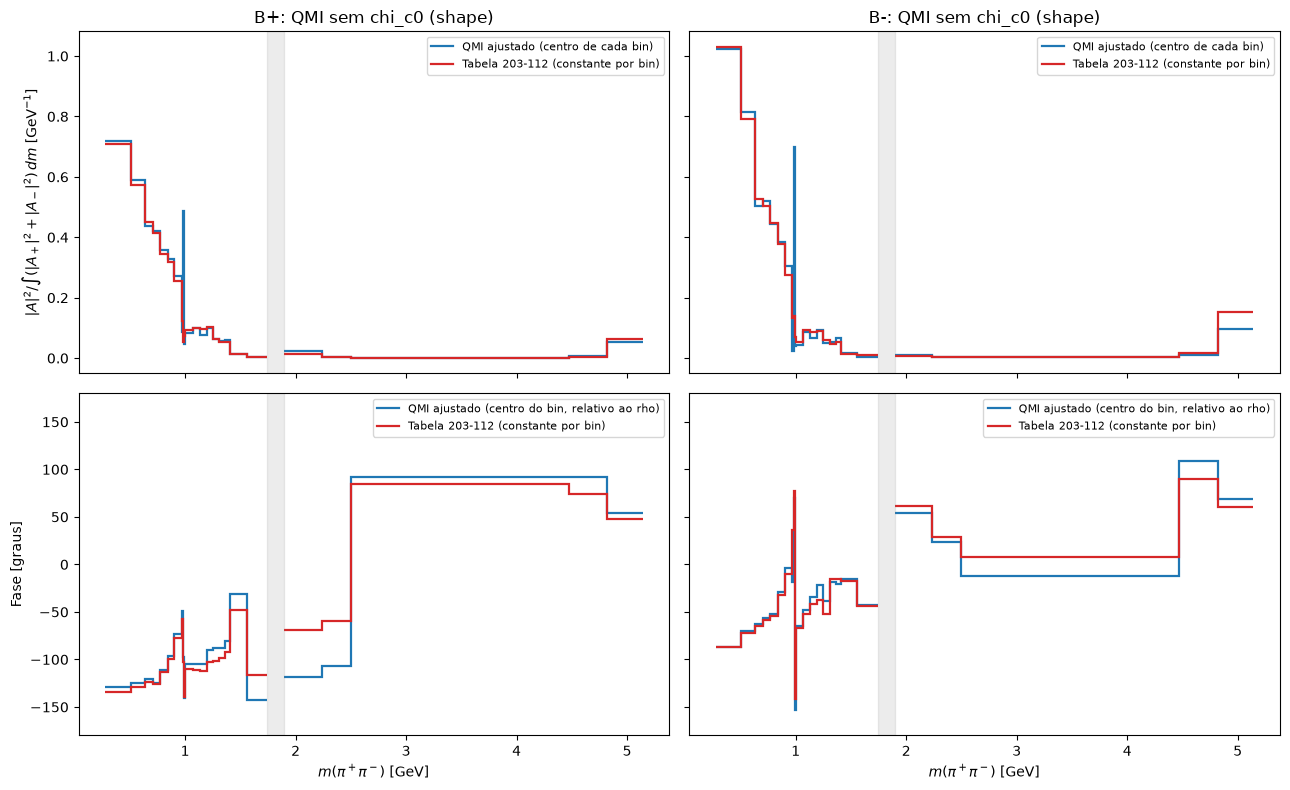

,charge,bin,mass_low_GeV,mass_high_GeV,outside_veto,fit_intensity_at_center,table_intensity,fit_phase_at_center_deg,table_phase_deg,phase_difference_deg
0,B+,1,0.27914,0.509015,True,0.72032,0.709473,-129.233,-133.929,4.69589
1,B+,2,0.509015,0.634185,True,0.590474,0.572294,-124.807,-129.044,4.23742
2,B+,3,0.634185,0.704998,True,0.438854,0.450094,-120.532,-124.004,3.47224
3,B+,4,0.704998,0.769832,True,0.422368,0.413612,-124.309,-125.587,1.27753
4,B+,5,0.769832,0.841871,True,0.357154,0.34391,-111.085,-113.355,2.27028
5,B+,6,0.841871,0.9013,True,0.328531,0.317958,-96.2883,-99.602,3.31373
6,B+,7,0.9013,0.97,True,0.272532,0.255671,-73.3359,-77.058,3.72206
7,B+,8,0.97,0.98,True,0.0863645,0.12309,-49.451,-56.944,7.49305
8,B+,9,0.98,0.99,True,0.487724,0.0539816,-97.0345,-103.109,6.07448
9,B+,10,0.99,1,True,0.0456032,0.0734091,-140.16,-139.79,-0.369669


In [61]:
# Imagens fornecidas pelo usuário: Tabela 28 + "203-112: SWave".
TABLE_MASS_EDGES_GEV = np.array([
    0.279140, 0.509015, 0.634185, 0.704998, 0.769832, 0.841871,
    0.901300, 0.970000, 0.980000, 0.990000, 1.000000, 1.070000,
    1.133000, 1.195000, 1.250000, 1.310000, 1.360000, 1.410000,
    1.556780, 1.740000, 1.894000, 2.236000, 2.500000, 4.472131,
    4.817487, 5.139690,
])
# Colunas: |A+|² impresso, delta+ [graus], |A-|² impresso, delta- [graus].
TABLE_SWAVE = np.array([
    [0.04784, -133.929, 0.06948, -87.310],
    [0.03859, -129.044, 0.05341, -72.456],
    [0.03035, -124.004, 0.03554, -65.002],
    [0.02789, -125.587, 0.03390, -58.909],
    [0.02319, -113.355, 0.03016, -54.771],
    [0.02144, -99.602, 0.02537, -32.422],
    [0.01724, -77.058, 0.01852, -10.049],
    [0.00830, -56.944, 0.00892, 36.186],
    [0.00364, -103.109, 0.00929, 76.942],
    [0.00495, -139.790, 0.00463, -141.810],
    [0.00625, -110.510, 0.00365, -66.370],
    [0.00673, -111.123, 0.00622, -52.224],
    [0.00651, -111.920, 0.00582, -41.931],
    [0.00688, -102.701, 0.00599, -37.457],
    [0.00434, -101.843, 0.00404, -51.732],
    [0.00352, -98.925, 0.00307, -15.635],
    [0.00351, -91.702, 0.00351, -15.827],
    [0.00085, -48.131, 0.00089, -17.899],
    [0.00025, -115.919, 0.00062, -44.178],
    [0.00000, -0.000, 0.00000, 0.000],
    [0.00082, -68.598, 0.00057, 61.740],
    [0.00019, -59.636, 0.00029, 28.417],
    [0.00004, 84.743, 0.00020, 8.092],
    [0.00020, 74.476, 0.00109, 90.238],
    [0.00420, 47.322, 0.01037, 60.449],
])
TABLE_INTENSITY_MULTIPLIER = 1e-2
COMPARISON_MODE = "shape"  # "shape" ou "absolute"
TABLE_PHASE_OFFSET_DEG = {"B+": 0.0, "B-": 0.0}  # somado às fases da tabela
assert TABLE_SWAVE.shape == (len(TABLE_MASS_EDGES_GEV) - 1, 4)
if COMPARISON_MODE not in ("shape", "absolute"):
    raise ValueError("COMPARISON_MODE deve ser shape ou absolute")

left, right = TABLE_MASS_EDGES_GEV[:-1], TABLE_MASS_EDGES_GEV[1:]
centers, widths = (left + right) / 2, right - left
outside_veto = (right <= D0_VETO_MIN_GEV) | (left >= D0_VETO_MAX_GEV)
reference_intensity = TABLE_SWAVE[:, [0, 2]] * TABLE_INTENSITY_MULTIPLIER

# Integral em dm apenas para a escala visual, calculada por bin e fora do veto.
gx, gw = np.polynomial.legendre.leggauss(64)
integration_mass = centers[:, None] + widths[:, None] * gx / 2
fitted_values_for_comparison = fit_session.result_values(result)
models_for_comparison = (plus_model, minus_model)
fit_integral = 0.0
for model in models_for_comparison:
    amp = swave_scan(model, fitted_values_for_comparison, integration_mass.ravel(), include_chic0=False)
    per_bin = (np.abs(amp.reshape(integration_mass.shape)) ** 2 @ gw) * widths / 2
    fit_integral += per_bin[outside_veto].sum()
table_integral = (reference_intensity.sum(axis=1) * widths)[outside_veto].sum()
fit_scale = fit_integral if COMPARISON_MODE == "shape" else 1.0
table_scale = table_integral if COMPARISON_MODE == "shape" else 1.0
if min(fit_scale, table_scale) <= 0:
    raise ValueError("Escala de comparação deve ser positiva")

wrap_phase = lambda phase: (phase + 180.0) % 360.0 - 180.0
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")
comparison_rows = []
for col, (label, model) in enumerate(zip(("B+", "B-"), models_for_comparison)):
    midpoint_amp = swave_scan(model, fitted_values_for_comparison, centers, include_chic0=False)
    table_phase = wrap_phase(TABLE_SWAVE[:, 2 * col + 1] + TABLE_PHASE_OFFSET_DEG[label])
    valid_phase = outside_veto & (reference_intensity[:, col] > 0)
    axes[0, col].stairs(
        np.where(outside_veto, np.abs(midpoint_amp) ** 2 / fit_scale, np.nan),
        TABLE_MASS_EDGES_GEV, baseline=None, color="tab:blue", linewidth=1.6,
        label="QMI ajustado (centro de cada bin)",
    )
    axes[0, col].stairs(
        np.where(outside_veto, reference_intensity[:, col] / table_scale, np.nan),
        TABLE_MASS_EDGES_GEV, baseline=None, color="tab:red", linewidth=1.6,
        label="Tabela 203-112 (constante por bin)",
    )
    midpoint_phase = wrap_phase(np.degrees(np.angle(midpoint_amp)))
    axes[1, col].stairs(
        np.where(outside_veto & (np.abs(midpoint_amp) > 0), midpoint_phase, np.nan),
        TABLE_MASS_EDGES_GEV, baseline=None, color="tab:blue", linewidth=1.6,
        label="QMI ajustado (centro do bin, relativo ao rho)",
    )
    axes[1, col].stairs(
        np.where(valid_phase, table_phase, np.nan), TABLE_MASS_EDGES_GEV,
        baseline=None, color="tab:red", linewidth=1.6,
        label="Tabela 203-112 (constante por bin)",
    )
    axes[0, col].set_title(f"{label}: QMI sem chi_c0 ({COMPARISON_MODE})")
    axes[1, col].set_ylim(-180, 180)
    axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
    for ax in axes[:, col]:
        ax.axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, color="grey", alpha=0.15)
        ax.legend(fontsize=8)
    for k in range(len(centers)):
        comparison_rows.append({
            "charge": label, "bin": k + 1, "mass_low_GeV": left[k], "mass_high_GeV": right[k],
            "outside_veto": bool(outside_veto[k]),
            "fit_intensity_at_center": abs(midpoint_amp[k]) ** 2 / fit_scale,
            "table_intensity": reference_intensity[k, col] / table_scale,
            "fit_phase_at_center_deg": wrap_phase(np.degrees(np.angle(midpoint_amp[k]))),
            "table_phase_deg": table_phase[k] if valid_phase[k] else np.nan,
            "phase_difference_deg": wrap_phase(np.degrees(np.angle(midpoint_amp[k])) - table_phase[k])
                                    if valid_phase[k] else np.nan,
        })
axes[0, 0].set_ylabel(r"$|A|^2 / \int (|A_+|^2+|A_-|^2)\,dm$ [GeV$^{-1}$]"
                       if COMPARISON_MODE == "shape" else r"$|A|^2$ (escala bruta)")
axes[1, 0].set_ylabel("Fase [graus]")
fig.tight_layout()
plt.show()
swave_table_comparison = pd.DataFrame(comparison_rows)
display(swave_table_comparison)


## Projeções pós-ajuste

`s13` (canal `pi± pi∓`), um painel por carga, com componente de background e curva total.

## Projeções dobradas (folded)

`s13` e `s23` são exatamente o par trocado pela simetrização das duas `pi+`/`pi-` idênticas
(`(0,2)` <-> `(1,2)` sob a troca `0<->1`), então `s_low=min(s13,s23)` e `s_high=max(s13,s23)`
são as duas projeções fisicamente distintas (não duas visões da mesma) recomendadas em
`docs/backgrounds_and_vetoes.md` para um par de partículas idênticas -- cada uma dobra os dados e
a projeção do ajuste dentro do painel de cada carga (B+ e B- nunca são misturados).

array([[<Axes: ylabel='Candidates / 0.231 GeV$^2$'>,
        <Axes: ylabel='Candidates / 0.231 GeV$^2$'>],
       [<Axes: xlabel='$s_{\\mathrm{low}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>,
        <Axes: xlabel='$s_{\\mathrm{low}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>]],
      dtype=object)

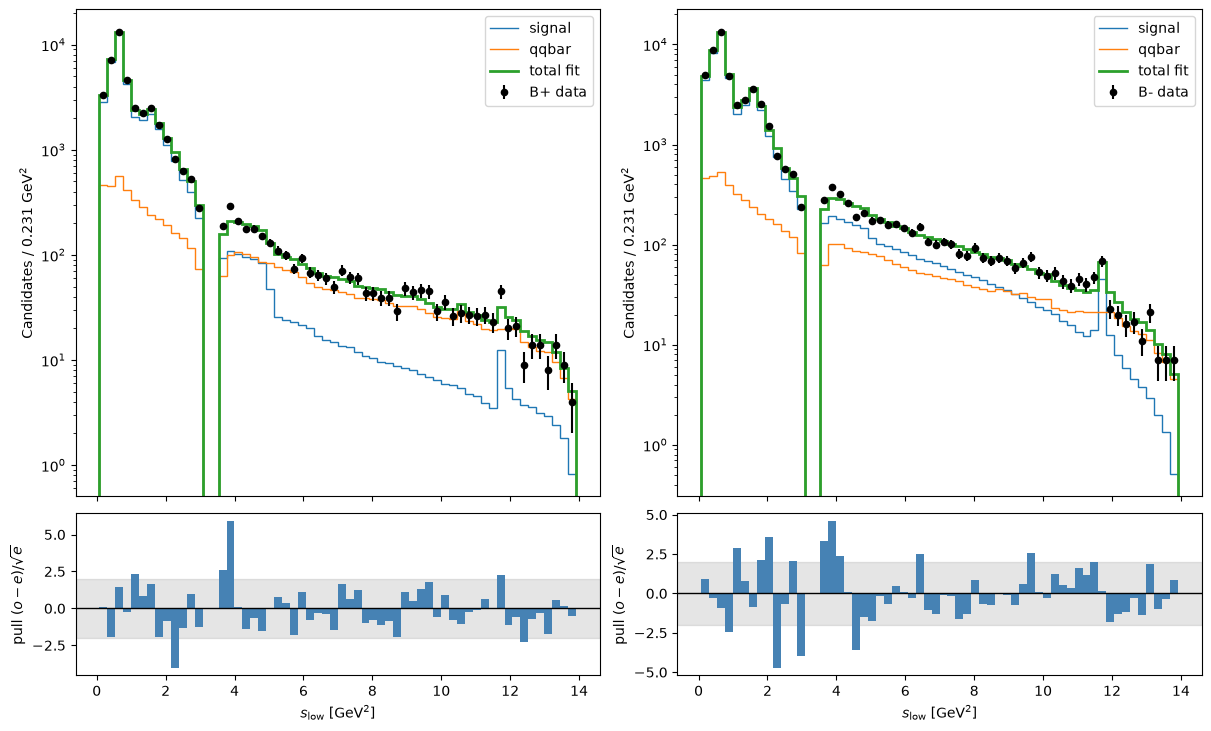

In [62]:
fit_session.plot_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="low",
    bins=60, show_components=True, show_pulls=True, projection_size=1_000_000, log_scale=True
)


array([[<Axes: ylabel='Candidates / 0.256 GeV$^2$'>,
        <Axes: ylabel='Candidates / 0.256 GeV$^2$'>],
       [<Axes: xlabel='$s_{\\mathrm{high}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>,
        <Axes: xlabel='$s_{\\mathrm{high}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>]],
      dtype=object)

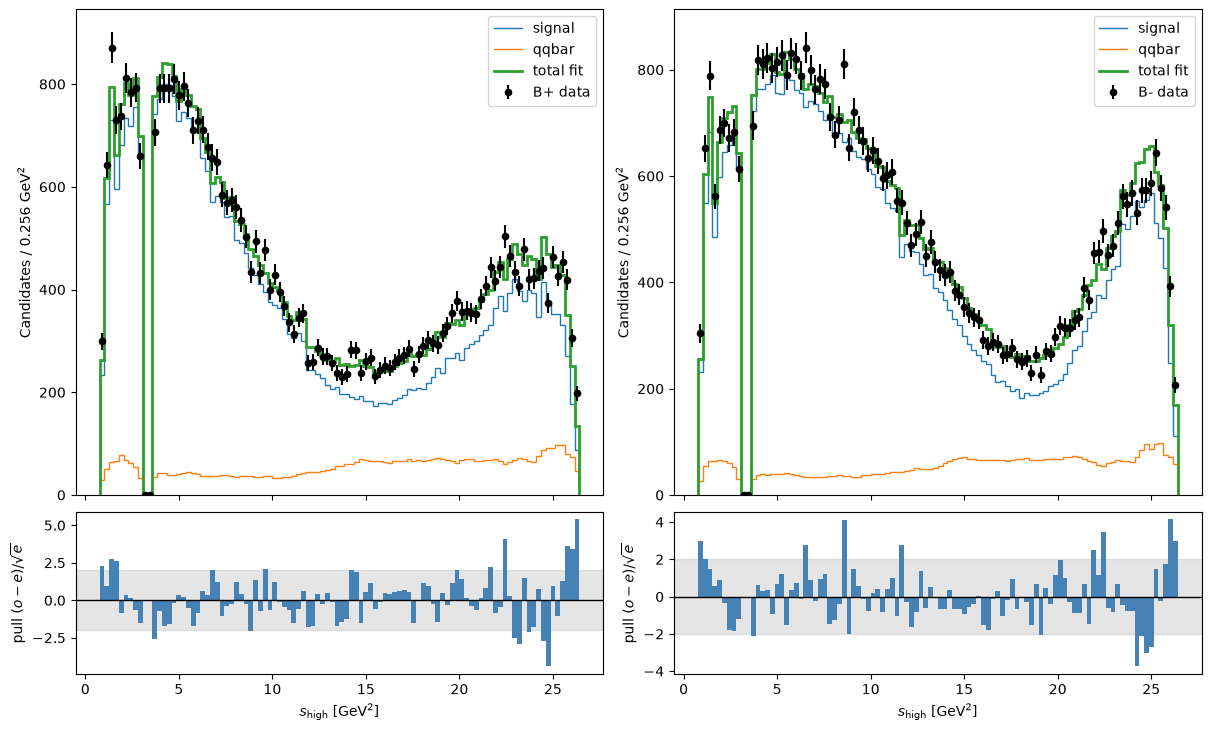

In [63]:
fit_session.plot_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="high",
    bins=100, show_components=True, show_pulls=True, projection_size=1_000_000
)


## Goodness-of-fit

Chi2 binado de Pearson no plano Square-Dalitz dobrado `(m', theta')` (mesmo par/convenção
`SQDP_PAIR`/`folded=True` usado para ACC e background acima), por carga -- ver
`docs/goodness_of_fit.md` para a leitura de `dof_min`/`dof_max`/`p_value_min`/`p_value_max`: como
os parâmetros vêm de um ajuste de máxima verossimilhança não-binado, o número exato de graus de
liberdade não é conhecido, e o resultado reporta as duas cotas de Williams (Sec. 3.1) em vez de um
único par dof/p-value potencialmente errado.

In [64]:
gof_square_dalitz = fit_session.goodness_of_fit_chi2(
    result, square_dalitz=True, folded=True,
    mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR,
    bins=25,
)
for charge, res in gof_square_dalitz.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  "
          f"p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")


plus: chi2=1169.7  n_bins=625  n_free_parameters=117
       dof in [507, 624]  p-value in [2.562e-54, 1.118e-35]
minus: chi2=1157.4  n_bins=625  n_free_parameters=117
       dof in [507, 624]  p-value in [8.407e-53, 1.984e-34]


### Resíduos no Dalitz convencional dobrado

Dados e expectativas são dobrados em `(min(s13,s23), max(s13,s23))`, como o ROOT atual.

In [65]:
gof_dp = fit_session.goodness_of_fit_chi2(result, x="s13", y="s23", folded=True, bins=25)
for charge, res in gof_dp.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")

plus: chi2=818.2  n_bins=367  n_free_parameters=117
       dof in [249, 366]  p-value in [8.258e-62, 1.31e-36]
minus: chi2=752.6  n_bins=366  n_free_parameters=117
       dof in [248, 365]  p-value in [2.804e-52, 4.211e-29]


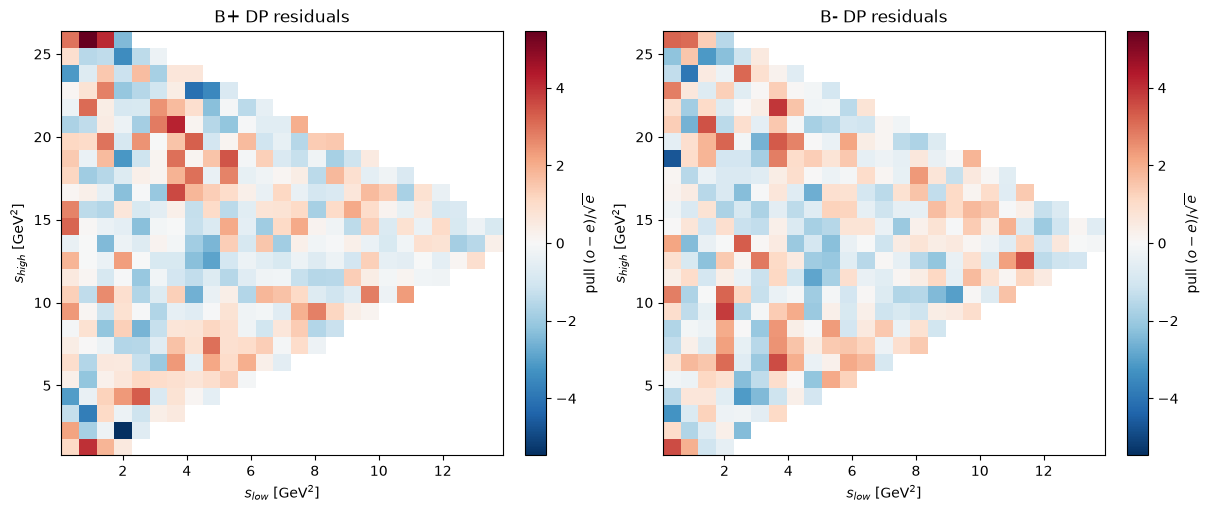

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pull_max = max(np.nanmax(np.abs(res.pulls)) for res in gof_dp.values())
for ax, (charge, res) in zip(axes, gof_dp.items()):
    x_edges, y_edges = res.edges
    mesh = ax.pcolormesh(x_edges, y_edges, res.pulls.T, cmap="RdBu_r", vmin=-pull_max, vmax=pull_max, shading="flat")
    ax.set_xlabel(r"$s_{low}$ [GeV$^2$]")
    ax.set_ylabel(r"$s_{high}$ [GeV$^2$]")
    ax.set_title(f"B{'+' if charge == 'plus' else '-'} DP residuals")
    fig.colorbar(mesh, ax=ax, label=r"pull $(o-e)/\sqrt{e}$")

### Mapa de resíduos no Dalitz Plot (Square-Dalitz)

`(observado - esperado) / sqrt(esperado)` por bin `(m', theta')`, mesma grade usada no chi2 acima
(`res.pulls`/`res.edges` de `BinnedChi2Result`). Bins sem eventos esperados (`expected <= 0`)
aparecem em branco (`nan`, excluídos do chi2). Um painel por carga, escala de cor divergente
centrada em zero.

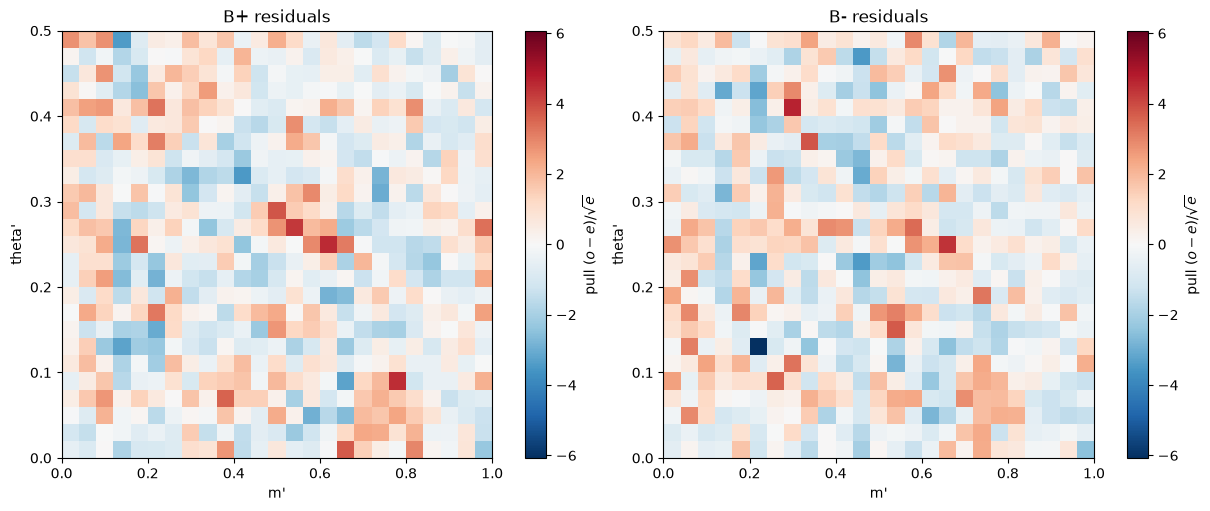

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pull_max = max(
    np.nanmax(np.abs(res.pulls)) for res in gof_square_dalitz.values()
)
for ax, (charge, res) in zip(axes, gof_square_dalitz.items()):
    mp_edges, tp_edges = res.edges
    mesh = ax.pcolormesh(
        mp_edges, tp_edges, res.pulls.T,
        cmap="RdBu_r", vmin=-pull_max, vmax=pull_max, shading="flat",
    )
    ax.set_xlabel("m'")
    ax.set_ylabel("theta'")
    ax.set_title(f"B{'+' if charge == 'plus' else '-'} residuals")
    fig.colorbar(mesh, ax=ax, label=r"pull $(o-e)/\sqrt{e}$")


Chi2 binado 1D na projeção dobrada `s_low` (mesma convenção da seção anterior), por carga.

In [68]:
gof_s_low = fit_session.goodness_of_fit_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="low", bins=60,
)
for charge, res in gof_s_low.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  "
          f"p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")


plus: chi2=133.1  n_bins=58  n_free_parameters=117
       dof in [-60, 57]  p-value in [nan, 5.016e-08]
minus: chi2=193.2  n_bins=58  n_free_parameters=117
       dof in [-60, 57]  p-value in [nan, 1.041e-16]


## Limites da comparação

A configuração usa CP por nó, sem normalização individual de nenhum componente e com
massas/larguras fixas, inclusive rho/f2, conforme solicitado. Os yields e a seleção permanecem os do ROOT local, e a proveniência dos
CSVs continua pendente. A interpolação configurada em s é uma escolha explícita, não uma equivalência
certificada com os bins do draft. Confirmar a origem dos inputs antes de reproduzir 212-112.

Após executar: inspecionar EDM/covariância, repetir inicializações e verificar estabilidade
de normalização. `valid=True` não garante um bom ajuste aos dados. NLLs absolutos não
são comparáveis sem igualar medida, domínio, constantes e seleção. Ao variar a quadratura,
reconstruir os modelos e a sessão, inclusive as normalizações de backgrounds.

### Resíduos adaptativos com KD-tree

In [69]:
# Resíduos locais adaptativos por k-vizinhos (KD-tree)
from dalitzplotfitter.kinematics import invariants_to_square_dalitz, fold_thetaprime

def _kdtree_points(charge, square=False, k=50, size=120_000):
    data = fit_session.plus_data if charge == "plus" else fit_session.minus_data
    sample = fit_session.plus_model.generate_phase_space(size, seed=20260911 if charge == "plus" else 20260912)
    other = fit_session.minus_model.generate_phase_space(size, seed=20260913 if charge == "plus" else 20260914)
    comps = fit_session._projection_components_pair(fit_session.result_values(result), sample, other)[0 if charge == "plus" else 1]
    exp_points, exp_weights = [], []
    for _, s, w in comps:
        d = s.as_dict()
        if square:
            a, b = invariants_to_square_dalitz(d["s12"], d["s13"], d["s23"], mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR)
            b = fold_thetaprime(b)
        else:
            a, b = jnp.minimum(d["s13"], d["s23"]), jnp.maximum(d["s13"], d["s23"])
        exp_points.append(np.column_stack((np.asarray(a), np.asarray(b))))
        exp_weights.append(np.asarray(w))
    d = data.as_dict()
    if square:
        a, b = invariants_to_square_dalitz(d["s12"], d["s13"], d["s23"], mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR)
        b = fold_thetaprime(b)
    else:
        a, b = jnp.minimum(d["s13"], d["s23"]), jnp.maximum(d["s13"], d["s23"])
    return kdtree_local_residuals(np.column_stack((np.asarray(a), np.asarray(b))), np.concatenate(exp_points), np.concatenate(exp_weights), k=k)

kdtree_residuals = {}
for coordinate in ("dp", "square"):
    for charge in ("plus", "minus"):
        pulls, observed_count, expected_count, radii = _kdtree_points(charge, square=coordinate == "square")
        kdtree_residuals[(coordinate, charge)] = pulls
        print(coordinate, charge, "median pull=", float(np.median(pulls)), "RMS=", float(np.std(pulls)))

dp plus median pull= 0.2647688406721048 RMS= 1.81457194953653
dp minus median pull= 0.23711147995771303 RMS= 1.7294578360832014
square plus median pull= 0.24938736270994835 RMS= 1.8468141278721681
square minus median pull= 0.23740244679782863 RMS= 1.7406722649421977


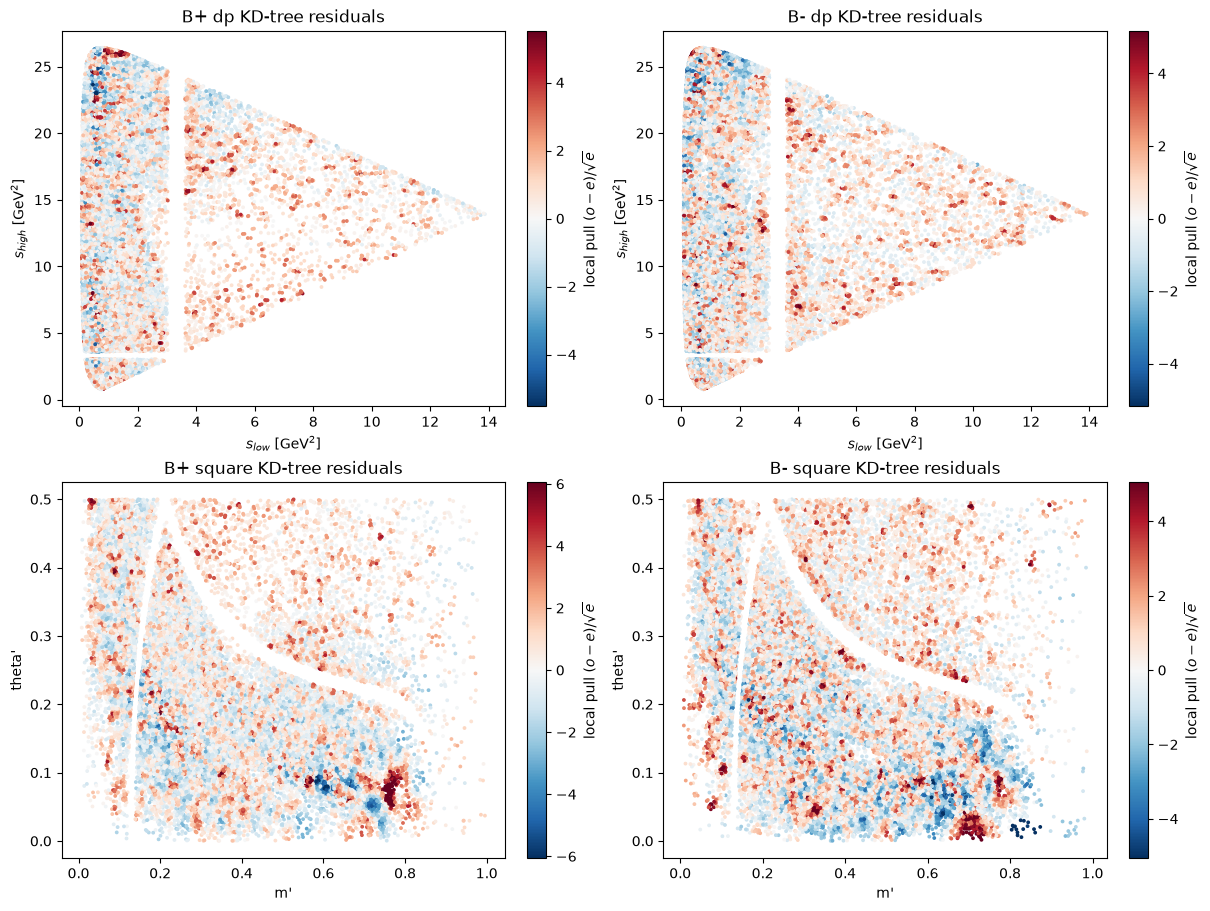

In [70]:
# KD-tree pull map: cada ponto observado recebe o pull da vizinhança local.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for row, coordinate in enumerate(("dp", "square")):
    for col, charge in enumerate(("plus", "minus")):
        data = fit_session.plus_data if charge == "plus" else fit_session.minus_data
        d = data.as_dict()
        if coordinate == "square":
            xx, yy = invariants_to_square_dalitz(d["s12"], d["s13"], d["s23"], mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR)
            yy = fold_thetaprime(yy)
            xlabel, ylabel = "m'", "theta'"
        else:
            xx, yy = jnp.minimum(d["s13"], d["s23"]), jnp.maximum(d["s13"], d["s23"])
            xlabel, ylabel = r"$s_{low}$ [GeV$^2$]", r"$s_{high}$ [GeV$^2$]"
        pulls = kdtree_residuals[(coordinate, charge)]
        scale = max(float(np.nanpercentile(np.abs(pulls), 99)), 1.0)
        mesh = axes[row, col].scatter(np.asarray(xx), np.asarray(yy), c=pulls, s=3, cmap="RdBu_r", vmin=-scale, vmax=scale, rasterized=True)
        axes[row, col].set(xlabel=xlabel, ylabel=ylabel, title=f"B{'+' if charge == 'plus' else '-'} {coordinate} KD-tree residuals")
        fig.colorbar(mesh, ax=axes[row, col], label=r"local pull $(o-e)/\sqrt{e}$")